# Ensemble analysis of the Monte Carlo v4 scenarios

This analysis brings together four campaigns with 10,000 trials each, combining Scenarios 1 and 2 with the Super Gaussian and Bastankhah wake models. The park of interest is New England Wind, referred to as `self` in the rest of the notebook. In addition to the self AEP and wake loss, this analysis includes the combined AEP of all active farms in the scenario, so it is possible to look at the self production and the energy growth of the whole world at the same time. The idea here is to understand how the scenarios change the results and how the two wake models respond to the same sampled worlds.

**Update:** the original checkpoint grid evaluated each segment's start year, so the last simulated snapshot was 2046, not 2050 -- the true full build-out year was never evaluated by the pipeline. `orchestrator.py` was fixed to add that missing snapshot (`segment_id=5`, `arrival_year <= 2050`, i.e. every farm in the trial), and the four campaigns were backfilled with it. Every "final checkpoint" figure and value in this notebook now uses that real 2050 state, not the 2046 stand-in the earlier version used -- expect AEP, wake loss, and capacity figures here to sit noticeably higher than an earlier read of this analysis.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.width", 160)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["font.size"] = 11

RESULTS = Path("../../results")
COLOR_S1 = "#2a78d6"   # Scenario 1 -- categorical slot 1
COLOR_S2 = "#eb6834"   # Scenario 2 -- categorical slot 2
COLOR_SG = "#2a78d6"   # Wake Model: SuperGaussian -- same slot 1, reused for model identity in Phase 4
COLOR_BK = "#eb6834"   # Wake Model: Bastankhah -- same slot 2, reused for model identity in Phase 4
COLOR_NEUTRAL = "#52514e"

## Data structure and model comparison

Each branch contains the `trials`, `arrivals`, and `segments` tables, as in the previous analysis. The difference now is that the same scenarios are simulated with two wake models, so the comparison can separate the effect of the scenario construction from the effect of the model used to calculate wakes. For each branch, the last segment is used as the main comparison point, with one final row per trial -- that last segment is now the real 2050 full build-out snapshot described above, not a mid-horizon one. The final table also includes the mean density of the farms that received a target density within each sampled world.

In [2]:
def load_branch(scenario, run_id):
    d = RESULTS / scenario / run_id / "merged"
    return (pd.read_parquet(d / "trials.parquet"),
            pd.read_parquet(d / "arrivals.parquet"),
            pd.read_parquet(d / "segments.parquet"))

trials_s1_sg, arrivals_s1_sg, segments_s1_sg = load_branch("scenario_1", "production_10k_s1_supergaussian")
trials_s1_bk, arrivals_s1_bk, segments_s1_bk = load_branch("scenario_1", "production_10k_s1_bastankhah")
trials_s2_sg, arrivals_s2_sg, segments_s2_sg = load_branch("scenario_2", "production_10k_s2_supergaussian")
trials_s2_bk, arrivals_s2_bk, segments_s2_bk = load_branch("scenario_2", "production_10k_s2_bastankhah")

In [3]:
# one row per trial, taken at the final checkpoint -- the true full build-out at YEAR_END (2050),
# not a mid-horizon segment start. Picked up automatically via .max() (segment_id now goes 0..5).
FINAL_SEGMENT = segments_s1_sg["segment_id"].max()
FINAL_SEGMENT

np.int64(5)

Density is still aggregated by trial, meaning the average of the target densities of the farms that received this draw. This average does not represent the density of a specific farm, but it helps describe the average level of build-out in each world. Since the wake models do not take part in generating the scenarios, density, arrival, turbine, and geometry values need to be the same between Super Gaussian and Bastankhah when the seed and scenario are the same.

In [4]:
def trial_density(arrivals):
    return arrivals.dropna(subset=["rho_target_mw_km2"]).groupby("trial_id")["rho_target_mw_km2"].mean().rename("mean_density_mw_km2")

def final_table(trials, segments, arrivals):
    return (segments[segments.segment_id == FINAL_SEGMENT]
            .merge(trials, on="trial_id")
            .merge(trial_density(arrivals), on="trial_id", how="left"))

final_s1_sg = final_table(trials_s1_sg, segments_s1_sg, arrivals_s1_sg)
final_s1_bk = final_table(trials_s1_bk, segments_s1_bk, arrivals_s1_bk)
final_s2_sg = final_table(trials_s2_sg, segments_s2_sg, arrivals_s2_sg)
final_s2_bk = final_table(trials_s2_bk, segments_s2_bk, arrivals_s2_bk)
final_s1_sg.shape, final_s1_bk.shape, final_s2_sg.shape, final_s2_bk.shape

((10000, 29), (10000, 29), (10000, 29), (10000, 29))

## Plot conventions

### Plot Helpers

In [5]:
def hist_with_percentiles(data, color, xlabel, ylabel, title, bins=40, qs=(10, 50, 90)):
    fig, ax = plt.subplots(figsize=(6.5, 3.5))
    ax.hist(data, bins=bins, color=color, alpha=0.85, edgecolor="white", linewidth=0.3)
    ymax = ax.get_ylim()[1]
    for q in qs:
        v = np.percentile(data, q)
        ax.axvline(v, color=COLOR_NEUTRAL, linestyle="--", linewidth=1)
        ax.text(v, ymax, f"P{q}", rotation=90, va="top", ha="right", fontsize=8, color=COLOR_NEUTRAL)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title)
    fig.tight_layout()
    return fig, ax

def convergence_bands(data, color, ylabel, title, n_shuffles=8, n_points=50, qs=(10, 50, 90)):
    data = np.asarray(data)
    n = len(data)
    grid = np.unique(np.linspace(200, n, n_points).astype(int))
    rng = np.random.default_rng(0)
    tracks = {q: np.empty((n_shuffles, len(grid))) for q in qs}
    for s in range(n_shuffles):
        shuffled = rng.permutation(data)
        for gi, g in enumerate(grid):
            window = shuffled[:g]
            for q in qs:
                tracks[q][s, gi] = np.percentile(window, q)
    fig, ax = plt.subplots(figsize=(6.5, 3.5))
    for q in qs:
        band = tracks[q]
        med = band.mean(axis=0)
        ax.fill_between(grid, band.min(axis=0), band.max(axis=0), color=color, alpha=0.15)
        ax.plot(grid, med, color=color, linewidth=1.8 if q == 50 else 1, linestyle="-" if q == 50 else "--")
        ax.annotate(f"P{q}", (grid[-1], med[-1]), xytext=(4, 0), textcoords="offset points",
                    fontsize=8, color=COLOR_NEUTRAL, va="center")
    ax.set_xlabel("Trials (Samples)"); ax.set_ylabel(ylabel); ax.set_title(title)
    fig.tight_layout()
    return fig, ax

def segment_trajectory(segments, color, ylabel, title, value_col):
    grouped = segments.groupby("start_year")[value_col]
    p10, p50, p90 = grouped.quantile(0.10), grouped.quantile(0.50), grouped.quantile(0.90)
    fig, ax = plt.subplots(figsize=(6.5, 3.5))
    ax.fill_between(p50.index, p10, p90, color=color, alpha=0.2, label="P10-P90")
    ax.plot(p50.index, p50, color=color, linewidth=2, marker="o", label="P50")
    ax.set_xlabel("Simulation Year"); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(frameon=False, fontsize=8)
    fig.tight_layout()
    return fig, ax

def binned_line_plot(x, y, color, xlabel, ylabel, title):
    fig, ax = plt.subplots(figsize=(6.5, 3.5))
    ax.plot(x, y, color=color, linewidth=2, marker="o", markersize=4)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title)
    fig.tight_layout()
    return fig, ax

def overlay_hist(data_a, label_a, color_a, data_b, label_b, color_b, xlabel, ylabel, title, bins=40):
    fig, ax = plt.subplots(figsize=(6.5, 3.5))
    ax.hist(data_a, bins=bins, color=color_a, alpha=0.5, label=label_a)
    ax.hist(data_b, bins=bins, color=color_b, alpha=0.5, label=label_b)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(frameon=False, fontsize=8)
    fig.tight_layout()
    return fig, ax

def overlay_trajectory(segments_a, label_a, color_a, segments_b, label_b, color_b, ylabel, title, value_col):
    fig, ax = plt.subplots(figsize=(6.5, 3.5))
    for segments, label, color in [(segments_a, label_a, color_a), (segments_b, label_b, color_b)]:
        grouped = segments.groupby("start_year")[value_col]
        p10, p50, p90 = grouped.quantile(0.10), grouped.quantile(0.50), grouped.quantile(0.90)
        ax.fill_between(p50.index, p10, p90, color=color, alpha=0.15)
        ax.plot(p50.index, p50, color=color, linewidth=2, marker="o", label=label)
    ax.set_xlabel("Simulation Year"); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(frameon=False, fontsize=8)
    fig.tight_layout()
    return fig, ax

## Scenario 1, Super Gaussian model

Scenario 1 starts with the real farms and the self as a reference, while the rest of the development appears over the horizon through speculative farms. This first section presents the full analysis for one of the models, including the new combined AEP variable for the scenario. In the following sections, when the same scenario is run with Bastankhah or when Scenario 2 is analyzed, the comments will be shorter and focused only on what changed.

## Scenario 1 -- Real farms + isolated self -- Wake Model: SuperGaussian

### Phase 1 -- Ingestion, Audit & Correlation Screening

### Initial audit

The campaign has 10,000 complete trials and 222,434 records in the `arrivals` table, since each world contains several farms. `segments` now has 60,000 rows because each trial has six snapshots: the five original 5-year checkpoints (2026, 2031, 2036, 2041, 2046) plus the true full build-out at 2050, backfilled after the pipeline fix described at the top of this notebook. Missing values in `arrivals` are expected because not all farms receive a target density, especially farms that already have a real layout or fixed parameters. There are no missing values in `trials` and `segments`, and the 10,000 `trial_id` values appear in both datasets, so all generated worlds reached the end of the simulation.

In [6]:
trials_s1_sg.shape, arrivals_s1_sg.shape, segments_s1_sg.shape

((10000, 13), (222434, 9), (60000, 16))

In [7]:
trials_s1_sg.isna().sum().sum(), arrivals_s1_sg.isna().sum().sum(), segments_s1_sg.isna().sum().sum()

(np.int64(0), np.int64(140000), np.int64(0))

In [8]:
trials_s1_sg.trial_id.nunique(), segments_s1_sg.trial_id.nunique()  # integrity: every trial reached the final segment

(10000, 10000)

### Input Uncertainty

### Sampled inputs

The climate controls remained centered on the mean wind rose, with mean rotation close to zero and speed and spread multipliers close to 1, as expected from the way the bootstrap was used. The mean density per trial was around 5.04 MW/km², with a median of 5.02 MW/km², remembering that this is an average across the farms inside each world and therefore varies less than the individual density. The number of speculative farms had a mean of 17.24, a median of 17, and ranged from 7 to 30, because the build-out follows the capacity target and may need more or fewer farms depending on the sampled area, density, and turbine.

In [9]:
trials_s1_sg[['climate_rotation_deg', 'climate_speed_multiplier', 'climate_spread_multiplier']].describe()

,climate_rotation_deg,climate_speed_multiplier,climate_spread_multiplier
count,10000.000000,10000.000000,10000.000000
mean,0.004905,1.000005,1.000182
std,1.451754,0.004794,0.025552
min,-3.935272,0.990664,0.941646
25%,-0.967548,0.996565,0.982683
50%,0.009613,1.000019,0.999843
75%,0.998158,1.003367,1.017706
max,3.935272,1.010155,1.070733


In [10]:
final_s1_sg['mean_density_mw_km2'].describe()

count    10000.000000
mean         5.044288
std          0.355881
min          3.871925
25%          4.792734
50%          5.022666
75%          5.276898
max          6.520006
Name: mean_density_mw_km2, dtype: float64

In [11]:
final_s1_sg['n_speculative'].describe()

count    10000.000000
mean        17.243400
std          3.144987
min          7.000000
25%         15.000000
50%         17.000000
75%         19.000000
max         30.000000
Name: n_speculative, dtype: float64

### Correlation vs Outputs

### Association between inputs and energy

The correlations are now calculated for two responses, the active AEP of the self and the combined AEP of the whole scenario. The self AEP shows how the park responds to climate and wakes from neighboring farms, while the combined AEP shows how much energy the whole world produces when all active farms are added together. These correlations are an exploratory reading, not proof of causality, because capacity, turbine count, number of farms, and geometry are part of the same sampled world and are related to each other.

In [12]:
predictors = ["climate_rotation_deg", "climate_speed_multiplier", "climate_spread_multiplier",
              "n_speculative", "mean_density_mw_km2", "active_mw", "n_active_turbines"]
targets = ["active_aep_gwh", "world_aep_gwh"]

pearson_s1_sg = final_s1_sg[predictors + targets].corr(method="pearson").loc[predictors, targets]
pearson_s1_sg

,active_aep_gwh,world_aep_gwh
climate_rotation_deg,0.023827,0.023372
climate_speed_multiplier,0.362470,0.212043
climate_spread_multiplier,0.042442,0.022098
n_speculative,-0.104340,0.310655
mean_density_mw_km2,0.029904,-0.260422
active_mw,-0.084934,0.816402
n_active_turbines,-0.055960,0.444664


In [13]:
spearman_s1_sg = final_s1_sg[predictors + targets].corr(method="spearman").loc[predictors, targets]
spearman_s1_sg

,active_aep_gwh,world_aep_gwh
climate_rotation_deg,0.023737,0.031432
climate_speed_multiplier,0.373622,0.231083
climate_spread_multiplier,0.041618,0.024051
n_speculative,-0.109259,0.335388
mean_density_mw_km2,0.043698,-0.285354
active_mw,-0.075093,0.742446
n_active_turbines,-0.051747,0.363972


In Super Gaussian, the active AEP of the self is most associated with the climate speed multiplier, with a correlation of 0.362, which makes sense because speed directly changes energy production; the number of speculative farms and the active capacity follow with a weaker negative association (around -0.10 and -0.08), since a larger build-out means more wake exposure. The combined AEP of the scenario is most associated with active capacity, with a correlation of 0.816, followed by the number of active turbines, with 0.445. Both correlations are noticeably weaker than a mid-horizon checkpoint would show: by 2050 nearly every trial has converged close to the same ~30 GW target, so there is less variation left in capacity itself to explain, and other factors -- turbine count, climate, density -- carry relatively more of the remaining variance.

In [14]:
pearson_s1_sg['active_aep_gwh'].sort_values(key=abs, ascending=False)  # ranked drivers of AEP Self

climate_speed_multiplier     0.362470
n_speculative               -0.104340
active_mw                   -0.084934
n_active_turbines           -0.055960
climate_spread_multiplier    0.042442
mean_density_mw_km2          0.029904
climate_rotation_deg         0.023827
Name: active_aep_gwh, dtype: float64

In [15]:
pearson_s1_sg['world_aep_gwh'].sort_values(key=abs, ascending=False)  # ranked drivers of AEP Combined Scenario

active_mw                    0.816402
n_active_turbines            0.444664
n_speculative                0.310655
mean_density_mw_km2         -0.260422
climate_speed_multiplier     0.212043
climate_rotation_deg         0.023372
climate_spread_multiplier    0.022098
Name: world_aep_gwh, dtype: float64

### Phase 2 -- Dual Energy & Risk Breakdown

### Density, arrival, and scenario scale

Individual density still follows the distribution used for speculative build-out, with more concentration in the central range and a tail toward higher values, allowing denser farms without making them the most common case. Farm arrivals increase toward the end of the horizon, as defined by the accelerated time distribution. Together, these two choices mean that the final number of turbines is not fixed, and each trial ends with a different scale even while following the same general scenario rule.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Turbine Density'}, xlabel='Turbine Density [MW/km²]', ylabel='Farms [count]'>)

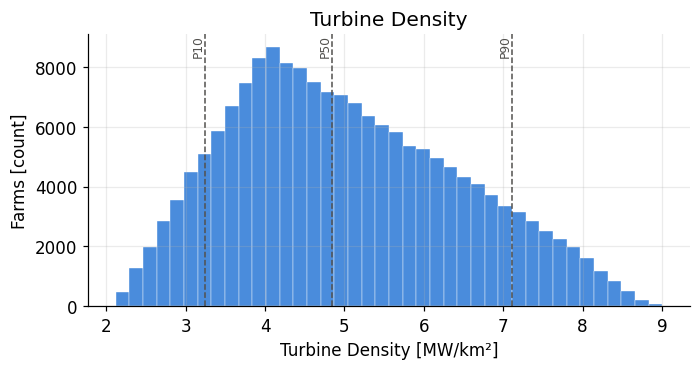

In [16]:
density = arrivals_s1_sg["rho_target_mw_km2"].dropna()
hist_with_percentiles(density, COLOR_SG, "Turbine Density [MW/km\u00b2]", "Farms [count]", "Turbine Density")

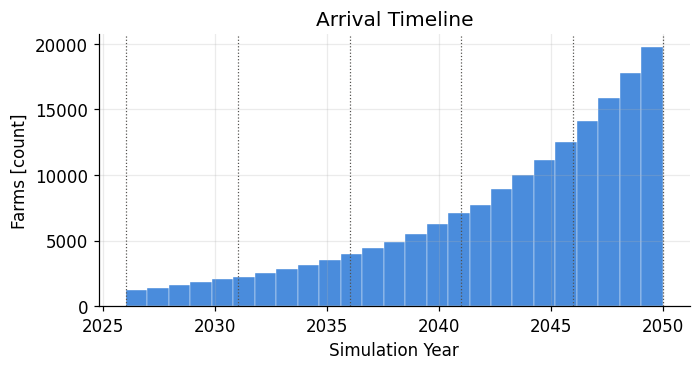

In [17]:
checkpoints = sorted(set(segments_s1_sg.start_year) | set(segments_s1_sg.end_year))
new_farm_years = arrivals_s1_sg.loc[arrivals_s1_sg.source == "speculative", "arrival_year"]
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.hist(new_farm_years, bins=25, color=COLOR_SG, alpha=0.85, edgecolor="white", linewidth=0.3)
for yr in checkpoints:
    ax.axvline(yr, color=COLOR_NEUTRAL, linestyle=":", linewidth=0.8)
ax.set_xlabel("Simulation Year"); ax.set_ylabel("Farms [count]"); ax.set_title("Arrival Timeline")
fig.tight_layout()

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Turbine Scale'}, xlabel='Active Turbines [count]', ylabel='Trials (Samples)'>)

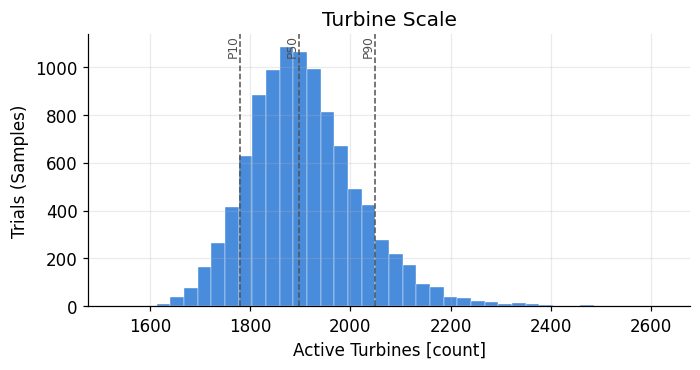

In [18]:
hist_with_percentiles(final_s1_sg["n_active_turbines"], COLOR_SG, "Active Turbines [count]", "Trials (Samples)", "Turbine Scale")

### Self AEP

The active AEP of the self at the last checkpoint includes the effect of neighboring farms. In Super Gaussian, the percentiles are approximately 2,984.0 GWh at P10, 3,077.9 GWh at the median, and 3,140.6 GWh at P90 -- lower across the board than a mid-horizon reading, since by 2050 more of the region has actually been built out and self has more neighbors to lose energy to. The range mainly appears because of the sampled climate, but it also includes differences in wake loss across the generated worlds.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'AEP Distribution'}, xlabel='AEP Self [GWh]', ylabel='Trials (Samples)'>)

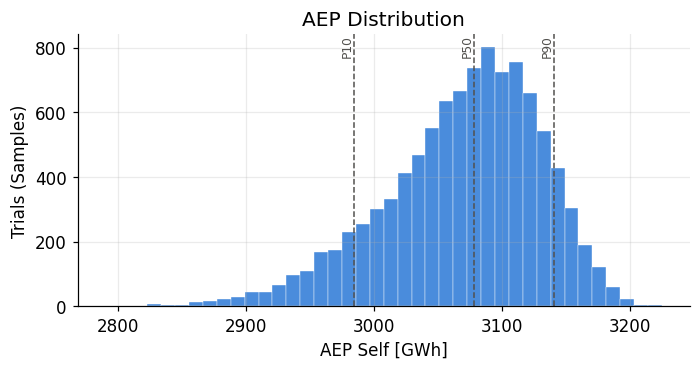

In [19]:
hist_with_percentiles(final_s1_sg["active_aep_gwh"], COLOR_SG, "AEP Self [GWh]", "Trials (Samples)", "AEP Distribution")

### Combined AEP of the scenario

The combined AEP adds the production of all active turbines at the last checkpoint, so it should not be interpreted as the energy of the self. It shows the energy scale of the world created in each trial. In Scenario 1 with Super Gaussian, P10 is approximately 108.0 TWh, the median is 111.8 TWh, and P90 is 117.3 TWh -- much higher than a mid-horizon reading, since the true 2050 snapshot includes the full ~30 GW of build-out instead of whatever had arrived partway through the horizon.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'AEP Distribution'}, xlabel='AEP Combined Scenario [TWh]', ylabel='Trials (Samples)'>)

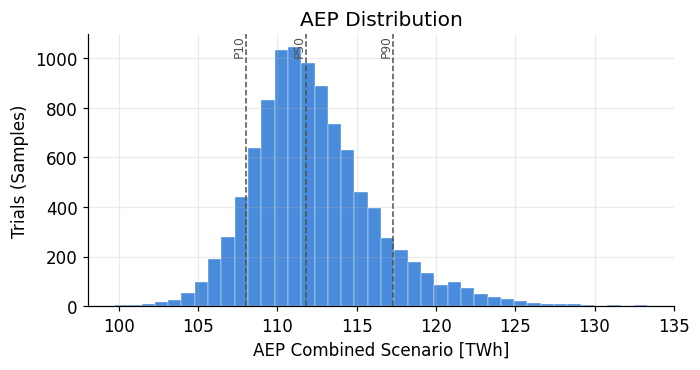

In [20]:
hist_with_percentiles(final_s1_sg["world_aep_gwh"] / 1000, COLOR_SG, "AEP Combined Scenario [TWh]", "Trials (Samples)", "AEP Distribution")

### Wake loss of the self

Wake loss in Scenario 1 with Super Gaussian has a median of 5.34%, a P10 of 3.65%, and a P90 of 8.11% -- higher than a mid-horizon reading across every percentile, since the true end state has more neighbors built out around the self. The distribution still has a tail toward higher values, so there is a group of worlds where the self is more exposed to wakes because of the combination of build-out, farm locations, and the time when they enter the scenario.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Wake Loss'}, xlabel='Wake Loss Self [%]', ylabel='Trials (Samples)'>)

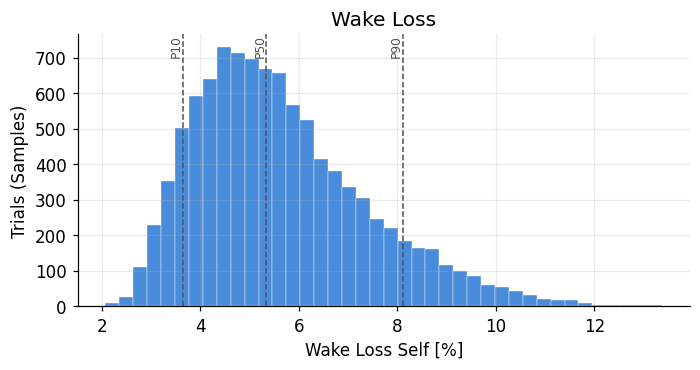

In [21]:
hist_with_percentiles(final_s1_sg["loss_pct"], COLOR_SG, "Wake Loss Self [%]", "Trials (Samples)", "Wake Loss")

The convergence plots check whether the percentiles used to summarize risk are already stable with 10,000 trials. The lines show P10, P50, and P90 calculated with a growing number of samples, and the bands show variation caused by the order in which trials enter. When the lines become nearly stable at the end, this indicates that the campaign is already estimating these percentiles consistently for this model and scenario.

In [22]:
np.percentile(final_s1_sg['active_aep_gwh'], [10, 50, 90])  # converged P10/P50/P90, AEP Self

array([2984.04494858, 3077.93418839, 3140.57926521])

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Risk Bands'}, xlabel='Trials (Samples)', ylabel='AEP Self [GWh]'>)

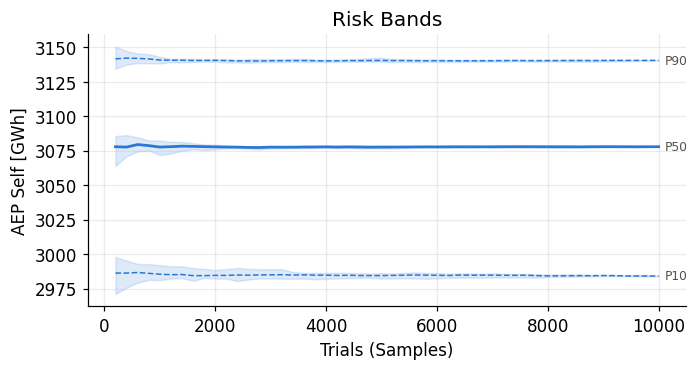

In [23]:
convergence_bands(final_s1_sg["active_aep_gwh"], COLOR_SG, "AEP Self [GWh]", "Risk Bands")

The same check is done here for combined AEP. Since this variable responds strongly to the total built capacity, it has a wider range between P10 and P90, but the plot shows whether this range and its percentiles keep changing as new trials are included or have already stabilized.

In [24]:
np.percentile(final_s1_sg['world_aep_gwh'] / 1000, [10, 50, 90])  # converged P10/P50/P90, AEP Combined

array([108.01873675, 111.79472075, 117.29081585])

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Risk Bands'}, xlabel='Trials (Samples)', ylabel='AEP Combined Scenario [TWh]'>)

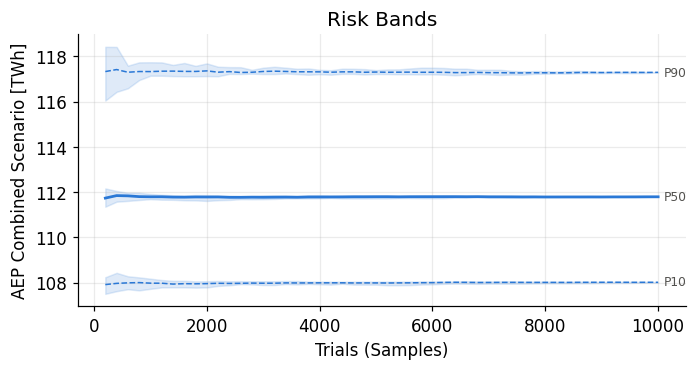

In [25]:
convergence_bands(final_s1_sg["world_aep_gwh"] / 1000, COLOR_SG, "AEP Combined Scenario [TWh]", "Risk Bands")

For wake loss, convergence is especially important for the tail percentiles. The median shows the most common result, but P90 represents the worlds with higher exposure, so the stability of this value helps use the campaign as a basis for a risk reading rather than only an average-value reading.

In [26]:
np.percentile(final_s1_sg['loss_pct'], [10, 50, 90])  # converged P10/P50/P90, Wake Loss Self

array([3.64907292, 5.34459681, 8.11212815])

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Risk Bands'}, xlabel='Trials (Samples)', ylabel='Wake Loss Self [%]'>)

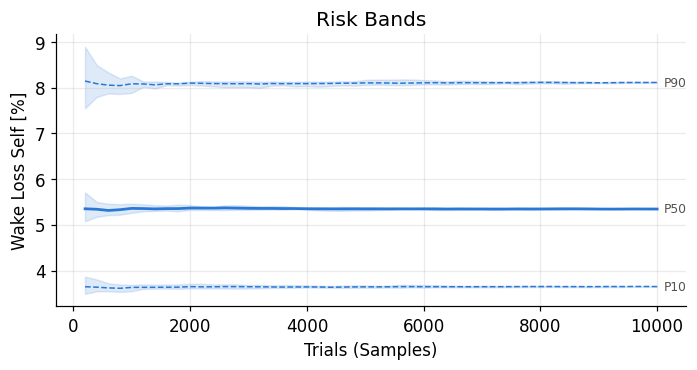

In [27]:
convergence_bands(final_s1_sg["loss_pct"], COLOR_SG, "Wake Loss Self [%]", "Risk Bands")

### Time evolution of wake loss

Median wake loss increases through Scenario 1 because more farms enter operation over time, now measured all the way out to the true 2050 endpoint instead of stopping at a mid-horizon checkpoint. The P10 to P90 band also opens toward the end of the horizon, showing that the worlds become more different from each other as density, capacity, location, and arrival decisions accumulate.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Loss Trajectory'}, xlabel='Simulation Year', ylabel='Wake Loss Self [%]'>)

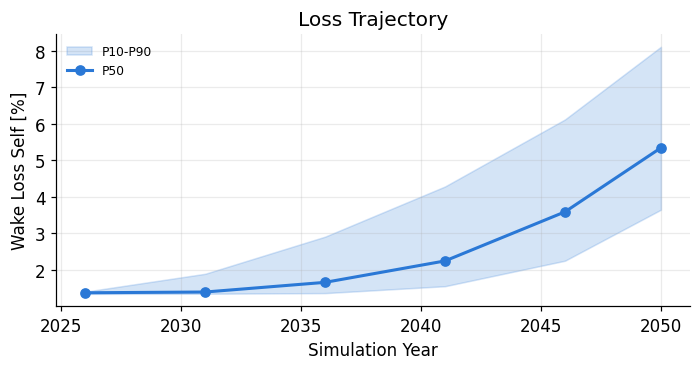

In [28]:
segment_trajectory(segments_s1_sg, COLOR_SG, "Wake Loss Self [%]", "Loss Trajectory", value_col="loss_pct")

Combined AEP grows over time because the scenario adds farms and active capacity, now reaching its true full-build-out level at 2050 rather than the earlier stand-in. This plot is important together with the wake loss plot because it shows the main trade-off in the study: the world produces more total energy as it develops, but this same growth can increase the self exposure to wakes.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Combined Energy Growth'}, xlabel='Simulation Year', ylabel='AEP Combined Scenario [TWh]'>)

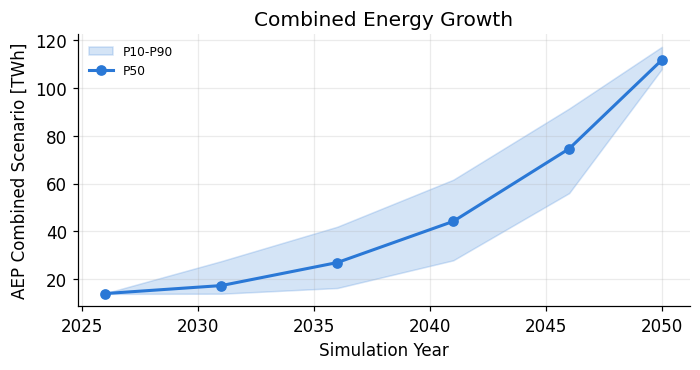

In [29]:
segments_s1_sg["world_aep_twh"] = segments_s1_sg["world_aep_gwh"] / 1000
segment_trajectory(segments_s1_sg, COLOR_SG, "AEP Combined Scenario [TWh]", "Combined Energy Growth", value_col="world_aep_twh")

### Phase 3 -- Regional Saturation & Cross-Variable Interaction

## Combined energy and effect on the self

After looking at each distribution separately, this section brings together the combined energy of the scenario and the wake loss of the self. The question is not whether more total energy is bad, since the goal of offshore development is precisely to increase regional production. The question is how this scenario growth appears together with the relative loss of the self, and whether there is a point where expansion starts to affect this park more clearly.

In [30]:
final_s1_sg[['world_aep_gwh', 'loss_pct']].corr().iloc[0, 1]  # Combined AEP growth vs Self wake loss, final segment

np.float64(0.10323311593768991)

In Scenario 1 with Super Gaussian, the correlation between combined AEP and wake loss is 0.103, much weaker than a mid-horizon reading would suggest. At the true 2050 endpoint almost every trial has converged to a similar total build-out (the ~30 GW target), so combined AEP alone stops being a useful predictor of how exposed the self actually is -- what varies between worlds now is less "how much got built" and more "where it got built," which this single scalar does not capture.

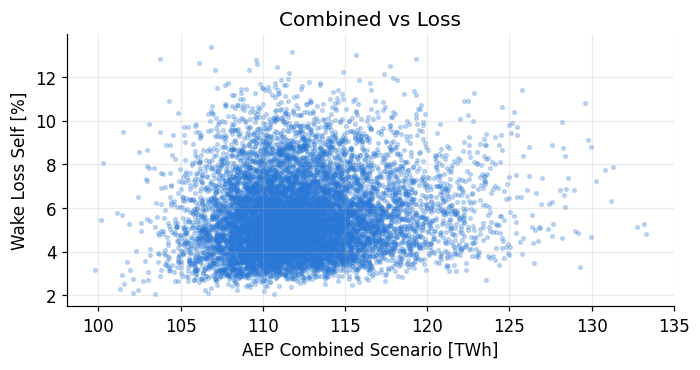

In [31]:
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.scatter(final_s1_sg["world_aep_gwh"] / 1000, final_s1_sg["loss_pct"], s=6, alpha=0.25, color=COLOR_SG)
ax.set_xlabel("AEP Combined Scenario [TWh]"); ax.set_ylabel("Wake Loss Self [%]"); ax.set_title("Combined vs Loss")
fig.tight_layout()

To look at this relationship in a more organized way, the segments are separated into active-capacity bins. In each bin, mean capacity, mean combined AEP, and mean active AEP of the self are calculated. This avoids reading only individual points and helps show how the average response changes as the system becomes larger.

In [32]:
capacity_bins_s1_sg = segments_s1_sg.copy()
capacity_bins_s1_sg["capacity_bin"] = pd.qcut(capacity_bins_s1_sg["active_mw"], 20, duplicates="drop")
sat_table_s1_sg = capacity_bins_s1_sg.groupby("capacity_bin", observed=True).agg(
    active_mw=("active_mw", "mean"),
    world_aep_twh=("world_aep_gwh", lambda x: x.mean() / 1000),
    active_aep_gwh=("active_aep_gwh", "mean"),
).reset_index(drop=True)
sat_table_s1_sg

,active_mw,world_aep_twh,active_aep_gwh
0,3644.512320,14.557828,3207.205176
1,5234.813716,20.642962,3199.866426
2,6180.643500,24.120998,3194.896929
3,7256.626209,28.052059,3189.068646
4,8550.265333,32.798558,3183.730045
5,10019.809627,38.122232,3176.072720
6,11731.939460,44.364872,3168.660282
7,13812.499833,51.898745,3157.007705
8,16264.730500,60.776781,3143.917351
9,18942.200667,70.333325,3130.491144


In [33]:
np.diff(sat_table_s1_sg['world_aep_twh'])  # marginal TWh gained per capacity bin -- shrinking values = saturation

array([ 6.08513372,  3.47803589,  3.93106093,  4.7464998 ,  5.32367324,
        6.24264054,  7.53387301,  8.87803532,  9.55654439,  9.8486161 ,
       17.79312548, 12.01193272,  1.8598963 ,  4.31288292])

Combined AEP increases continuously with active capacity, going from approximately 14.6 TWh in the lowest bin to 116.2 TWh in the highest bin. Saturation here does not mean that total energy stopped growing; the plot shows the opposite, since more capacity continues to add energy to the scenario, now visibly all the way out to the true 2050 build-out level. The point for the following analyses is to compare this regional gain with what happens to the self AEP at the same time.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Capacity Saturation'}, xlabel='Active Capacity [MW]', ylabel='AEP Combined Scenario [TWh]'>)

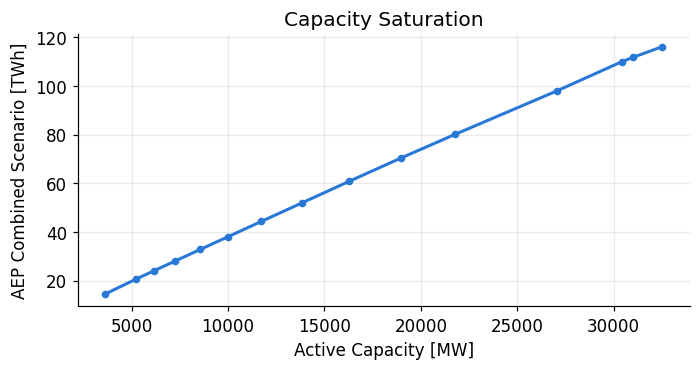

In [34]:
binned_line_plot(sat_table_s1_sg["active_mw"], sat_table_s1_sg["world_aep_twh"], COLOR_SG,
                  "Active Capacity [MW]", "AEP Combined Scenario [TWh]", "Capacity Saturation")

While combined AEP grows with capacity, the self AEP decreases from approximately 3,207 GWh to 3,063 GWh between the lowest and highest active-capacity bins -- a larger drop than a mid-horizon reading showed, now that the top bin reflects trials genuinely near full build-out. This shows the relationship the scenario was designed to explore: the whole system gains energy with expansion, but the self can lose part of its active production because it is inside an environment with more wakes.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Self Degradation'}, xlabel='Active Capacity [MW]', ylabel='AEP Self [GWh]'>)

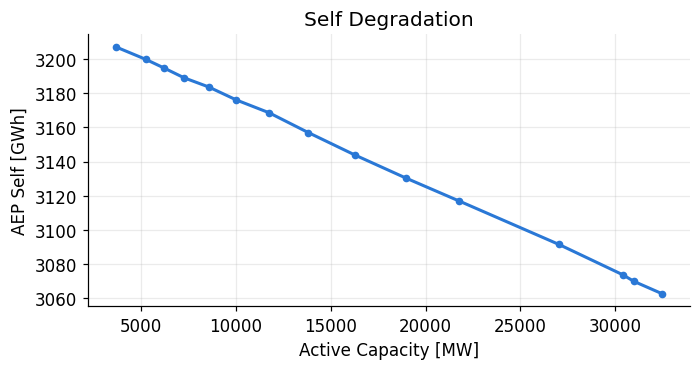

In [35]:
binned_line_plot(sat_table_s1_sg["active_mw"], sat_table_s1_sg["active_aep_gwh"], COLOR_SG,
                  "Active Capacity [MW]", "AEP Self [GWh]", "Self Degradation")

## Scenario 1, Bastankhah model

The same Scenario 1 is now evaluated with Bastankhah. The worlds are not generated again; only the wakes are recalculated with another model. For this reason, before comparing the energy results, it is important to confirm that the inputs and layouts are exactly the same as those used with Super Gaussian.

## Scenario 1 -- Real farms + isolated self -- Wake Model: Bastankhah

### Phase 1 -- Ingestion, Audit & Correlation Screening

In [36]:
trials_s1_bk.shape, arrivals_s1_bk.shape, segments_s1_bk.shape

((10000, 13), (222434, 9), (60000, 16))

In [37]:
trials_s1_bk.isna().sum().sum(), arrivals_s1_bk.isna().sum().sum(), segments_s1_bk.isna().sum().sum()

(np.int64(0), np.int64(140000), np.int64(0))

In [38]:
trials_s1_bk.trial_id.nunique(), segments_s1_bk.trial_id.nunique()  # integrity: every trial reached the final segment

(10000, 10000)

The audit appears again with the same table sizes -- including the 60,000-row `segments` table with the backfilled 2050 snapshot -- and no new missing values outside what was expected. More importantly, the test below returns `True` for the columns that define each trial and for the arrivals table. This confirms that seed, climate, farm count, density, capacity, geometry, and schedule are the same between the two models, so the differences from this point forward are differences in the wake calculation, not different scenarios.

In [39]:
# scenario generation never touches model_name (PIPELINE.md) -- trials/arrivals should be byte-identical to the SuperGaussian branch
cols = ["seed", "n_speculative", "fixed_capacity_mw", "climate_rotation_deg", "climate_speed_multiplier", "climate_spread_multiplier"]
trials_s1_bk[cols].equals(trials_s1_sg[cols]), arrivals_s1_bk.equals(arrivals_s1_sg)

(True, True)

### Input Uncertainty

The climate, mean-density, and farm-count statistics are the same as those seen with Super Gaussian, as expected, so there is no need to reinterpret these distributions here. What changes now are the responses calculated by the Bastankhah model for these same worlds.

In [40]:
trials_s1_bk[['climate_rotation_deg', 'climate_speed_multiplier', 'climate_spread_multiplier']].describe()

,climate_rotation_deg,climate_speed_multiplier,climate_spread_multiplier
count,10000.000000,10000.000000,10000.000000
mean,0.004905,1.000005,1.000182
std,1.451754,0.004794,0.025552
min,-3.935272,0.990664,0.941646
25%,-0.967548,0.996565,0.982683
50%,0.009613,1.000019,0.999843
75%,0.998158,1.003367,1.017706
max,3.935272,1.010155,1.070733


In [41]:
final_s1_bk['mean_density_mw_km2'].describe()

count    10000.000000
mean         5.044288
std          0.355881
min          3.871925
25%          4.792734
50%          5.022666
75%          5.276898
max          6.520006
Name: mean_density_mw_km2, dtype: float64

In [42]:
final_s1_bk['n_speculative'].describe()

count    10000.000000
mean        17.243400
std          3.144987
min          7.000000
25%         15.000000
50%         17.000000
75%         19.000000
max         30.000000
Name: n_speculative, dtype: float64

### Correlation vs Outputs

In [43]:
predictors = ["climate_rotation_deg", "climate_speed_multiplier", "climate_spread_multiplier",
              "n_speculative", "mean_density_mw_km2", "active_mw", "n_active_turbines"]
targets = ["active_aep_gwh", "world_aep_gwh"]

pearson_s1_bk = final_s1_bk[predictors + targets].corr(method="pearson").loc[predictors, targets]
pearson_s1_bk

,active_aep_gwh,world_aep_gwh
climate_rotation_deg,0.025953,0.017387
climate_speed_multiplier,0.512077,0.201339
climate_spread_multiplier,0.051160,0.017672
n_speculative,-0.076684,0.262280
mean_density_mw_km2,0.014347,-0.222295
active_mw,-0.080750,0.868521
n_active_turbines,-0.038075,0.502085


In [44]:
spearman_s1_bk = final_s1_bk[predictors + targets].corr(method="spearman").loc[predictors, targets]
spearman_s1_bk

,active_aep_gwh,world_aep_gwh
climate_rotation_deg,0.023973,0.024736
climate_speed_multiplier,0.523064,0.226786
climate_spread_multiplier,0.049096,0.020452
n_speculative,-0.081734,0.296910
mean_density_mw_km2,0.026494,-0.257764
active_mw,-0.069359,0.799059
n_active_turbines,-0.033181,0.417419


The same general pattern appears here: combined AEP remains most associated with active capacity, with a correlation of 0.869, and turbine count, with 0.502. For the self AEP, the speed multiplier has an even stronger association, 0.512, while capacity remains negatively associated because more development increases wake exposure. As with Super Gaussian, these correlations are weaker than a mid-horizon reading would show, for the same reason: by 2050 capacity itself has converged close to the ~30 GW target across almost every trial.

In [45]:
pearson_s1_bk['active_aep_gwh'].sort_values(key=abs, ascending=False)  # ranked drivers of AEP Self

climate_speed_multiplier     0.512077
active_mw                   -0.080750
n_speculative               -0.076684
climate_spread_multiplier    0.051160
n_active_turbines           -0.038075
climate_rotation_deg         0.025953
mean_density_mw_km2          0.014347
Name: active_aep_gwh, dtype: float64

In [46]:
pearson_s1_bk['world_aep_gwh'].sort_values(key=abs, ascending=False)  # ranked drivers of AEP Combined Scenario

active_mw                    0.868521
n_active_turbines            0.502085
n_speculative                0.262280
mean_density_mw_km2         -0.222295
climate_speed_multiplier     0.201339
climate_spread_multiplier    0.017672
climate_rotation_deg         0.017387
Name: world_aep_gwh, dtype: float64

### Phase 2 -- Dual Energy & Risk Breakdown

Since scenario generation was confirmed to be the same, the density, arrival-year, and turbine-count distributions are the same as in the previous block. For this reason, the focus here is only on the energy and wake-loss results calculated by Bastankhah.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Turbine Density'}, xlabel='Turbine Density [MW/km²]', ylabel='Farms [count]'>)

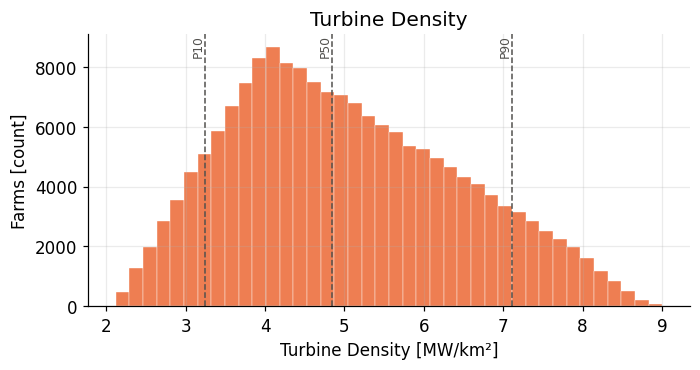

In [47]:
density = arrivals_s1_bk["rho_target_mw_km2"].dropna()
hist_with_percentiles(density, COLOR_BK, "Turbine Density [MW/km\u00b2]", "Farms [count]", "Turbine Density")

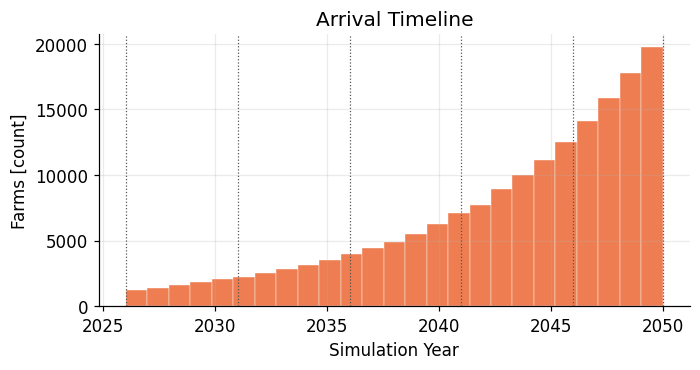

In [48]:
checkpoints = sorted(set(segments_s1_bk.start_year) | set(segments_s1_bk.end_year))
new_farm_years = arrivals_s1_bk.loc[arrivals_s1_bk.source == "speculative", "arrival_year"]
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.hist(new_farm_years, bins=25, color=COLOR_BK, alpha=0.85, edgecolor="white", linewidth=0.3)
for yr in checkpoints:
    ax.axvline(yr, color=COLOR_NEUTRAL, linestyle=":", linewidth=0.8)
ax.set_xlabel("Simulation Year"); ax.set_ylabel("Farms [count]"); ax.set_title("Arrival Timeline")
fig.tight_layout()

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Turbine Scale'}, xlabel='Active Turbines [count]', ylabel='Trials (Samples)'>)

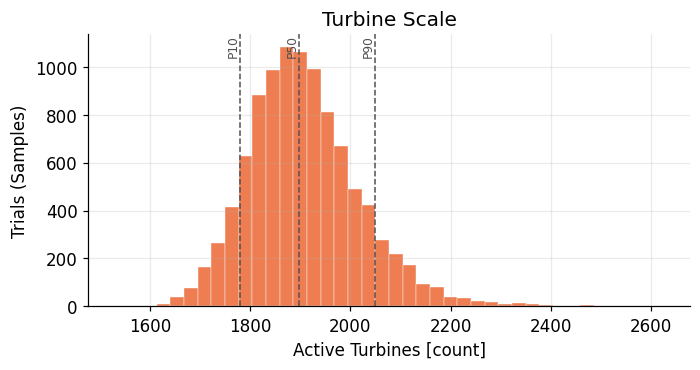

In [49]:
hist_with_percentiles(final_s1_bk["n_active_turbines"], COLOR_BK, "Active Turbines [count]", "Trials (Samples)", "Turbine Scale")

With Bastankhah, the active AEP of the self is at a different level, with a P10 of approximately 3,196.7 GWh, a median of 3,260.4 GWh, and a P90 of 3,307.7 GWh. These values are higher than those obtained with Super Gaussian for the same scenario, which already indicates that Bastankhah is calculating lower losses for these worlds -- the same gap seen at a mid-horizon reading, now larger in absolute GWh because the true 2050 state has more total build-out for the gap to act on.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'AEP Distribution'}, xlabel='AEP Self [GWh]', ylabel='Trials (Samples)'>)

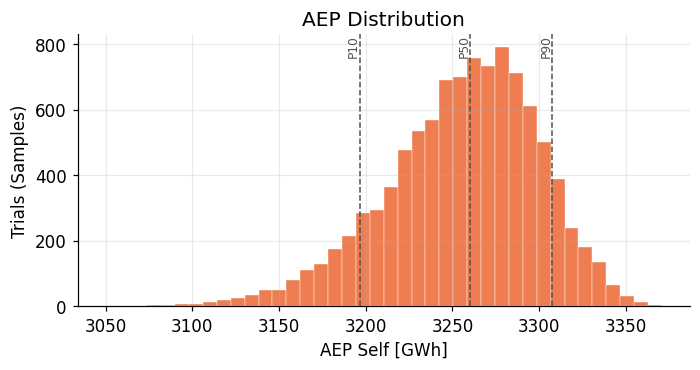

In [50]:
hist_with_percentiles(final_s1_bk["active_aep_gwh"], COLOR_BK, "AEP Self [GWh]", "Trials (Samples)", "AEP Distribution")

Combined AEP is also higher with Bastankhah, with a median of approximately 120.2 TWh, compared with 111.8 TWh for Super Gaussian. Since capacity, farms, and climate are the same, this difference comes from how each model represents wake interactions across the whole scenario.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'AEP Distribution'}, xlabel='AEP Combined Scenario [TWh]', ylabel='Trials (Samples)'>)

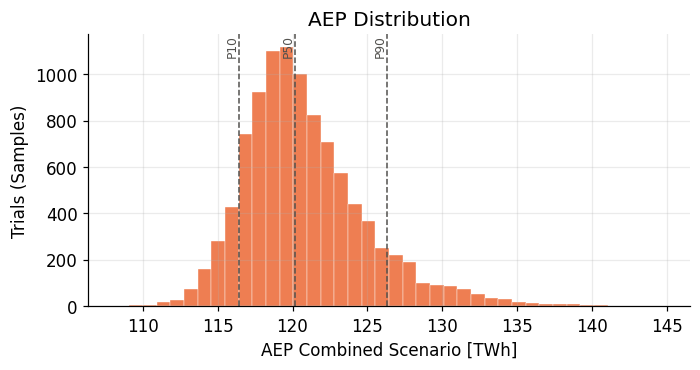

In [51]:
hist_with_percentiles(final_s1_bk["world_aep_gwh"] / 1000, COLOR_BK, "AEP Combined Scenario [TWh]", "Trials (Samples)", "AEP Distribution")

Wake loss of the self with Bastankhah has a P10 of 1.99%, a median of 3.07%, and a P90 of 4.82%. Compared with Super Gaussian, the distribution still shifts toward lower losses at every percentile, and both distributions have moved up together relative to a mid-horizon reading now that the true 2050 build-out is being evaluated.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Wake Loss'}, xlabel='Wake Loss Self [%]', ylabel='Trials (Samples)'>)

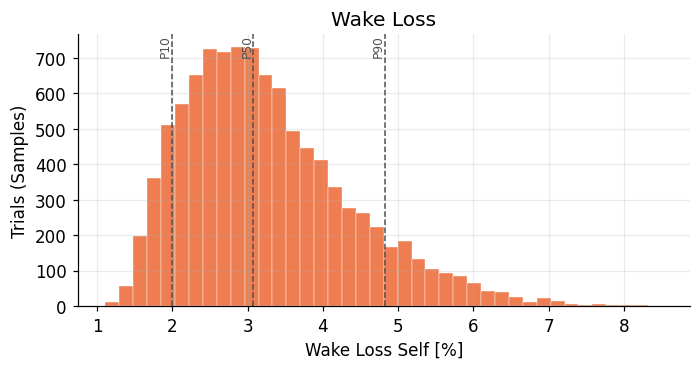

In [52]:
hist_with_percentiles(final_s1_bk["loss_pct"], COLOR_BK, "Wake Loss Self [%]", "Trials (Samples)", "Wake Loss")

Convergence is checked again to make sure that the Bastankhah percentiles are not also a result of trial order. The behavior is the same as in the previous block: after many trials, the bands stabilize and the final percentiles can be compared with Super Gaussian with more confidence.

In [53]:
np.percentile(final_s1_bk['active_aep_gwh'], [10, 50, 90])  # converged P10/P50/P90, AEP Self

array([3196.67885065, 3260.36663221, 3307.65955075])

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Risk Bands'}, xlabel='Trials (Samples)', ylabel='AEP Self [GWh]'>)

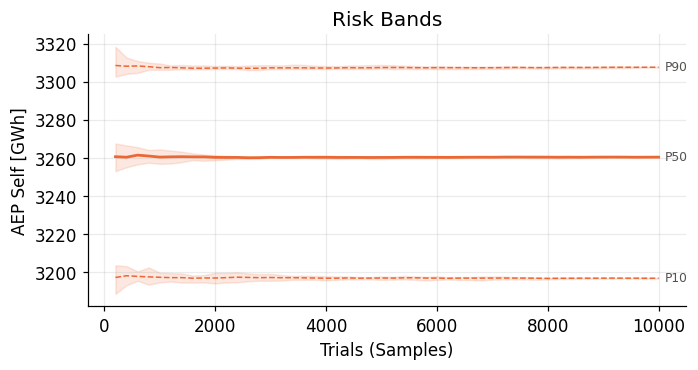

In [54]:
convergence_bands(final_s1_bk["active_aep_gwh"], COLOR_BK, "AEP Self [GWh]", "Risk Bands")

In [55]:
np.percentile(final_s1_bk['world_aep_gwh'] / 1000, [10, 50, 90])  # converged P10/P50/P90, AEP Combined

array([116.41818477, 120.16880583, 126.30783231])

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Risk Bands'}, xlabel='Trials (Samples)', ylabel='AEP Combined Scenario [TWh]'>)

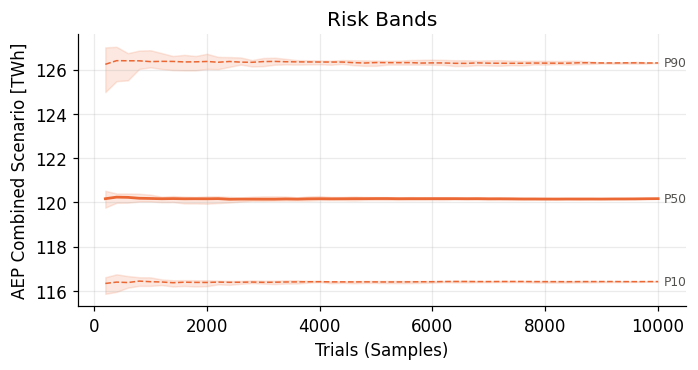

In [56]:
convergence_bands(final_s1_bk["world_aep_gwh"] / 1000, COLOR_BK, "AEP Combined Scenario [TWh]", "Risk Bands")

In [57]:
np.percentile(final_s1_bk['loss_pct'], [10, 50, 90])  # converged P10/P50/P90, Wake Loss Self

array([1.98903689, 3.07481931, 4.81855482])

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Risk Bands'}, xlabel='Trials (Samples)', ylabel='Wake Loss Self [%]'>)

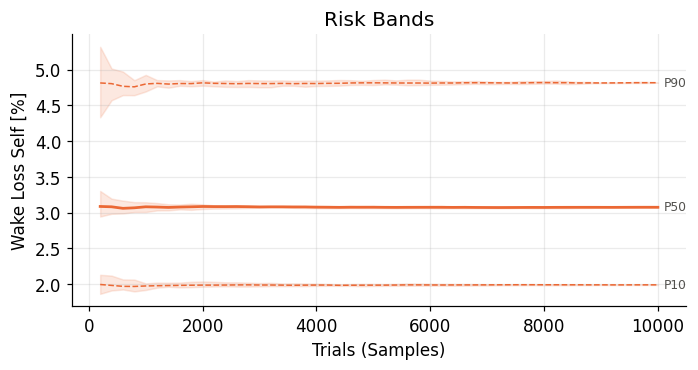

In [58]:
convergence_bands(final_s1_bk["loss_pct"], COLOR_BK, "Wake Loss Self [%]", "Risk Bands")

The time trajectory repeats the regional growth seen before: combined AEP increases as new farms enter, and wake loss also increases, but at a lower level than with Super Gaussian, now visibly out to the true 2050 endpoint. So the time pattern does not disappear when the model changes; what changes is the magnitude of the calculated loss.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Loss Trajectory'}, xlabel='Simulation Year', ylabel='Wake Loss Self [%]'>)

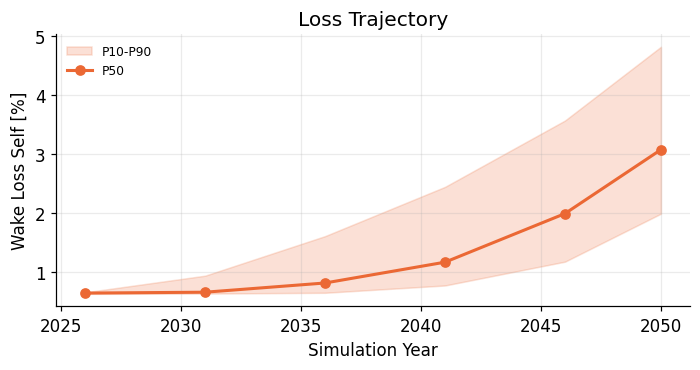

In [59]:
segment_trajectory(segments_s1_bk, COLOR_BK, "Wake Loss Self [%]", "Loss Trajectory", value_col="loss_pct")

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Combined Energy Growth'}, xlabel='Simulation Year', ylabel='AEP Combined Scenario [TWh]'>)

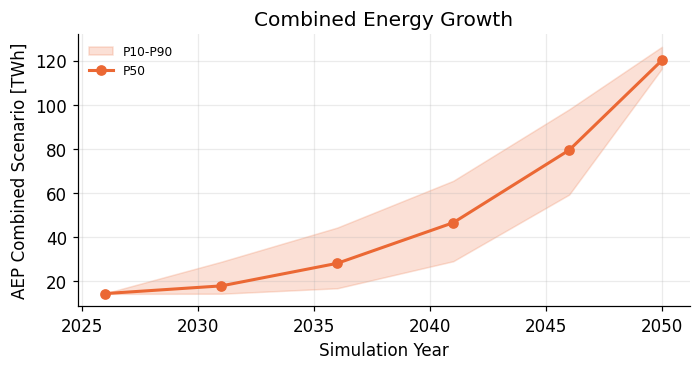

In [60]:
segments_s1_bk["world_aep_twh"] = segments_s1_bk["world_aep_gwh"] / 1000
segment_trajectory(segments_s1_bk, COLOR_BK, "AEP Combined Scenario [TWh]", "Combined Energy Growth", value_col="world_aep_twh")

### Phase 3 -- Regional Saturation & Cross-Variable Interaction

In [61]:
final_s1_bk[['world_aep_gwh', 'loss_pct']].corr().iloc[0, 1]  # Combined AEP growth vs Self wake loss, final segment

np.float64(0.09829127730441695)

The association between combined AEP and wake loss is 0.098, essentially the same near-zero reading seen with Super Gaussian (0.103). This confirms it is not a model artifact: at the true 2050 endpoint, both models agree that total combined AEP has stopped being a useful predictor of the self's wake exposure once nearly every trial has converged toward the same ~30 GW target.

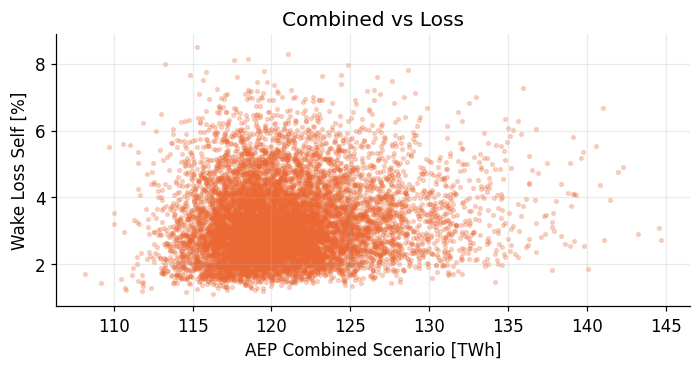

In [62]:
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.scatter(final_s1_bk["world_aep_gwh"] / 1000, final_s1_bk["loss_pct"], s=6, alpha=0.25, color=COLOR_BK)
ax.set_xlabel("AEP Combined Scenario [TWh]"); ax.set_ylabel("Wake Loss Self [%]"); ax.set_title("Combined vs Loss")
fig.tight_layout()

In [63]:
capacity_bins_s1_bk = segments_s1_bk.copy()
capacity_bins_s1_bk["capacity_bin"] = pd.qcut(capacity_bins_s1_bk["active_mw"], 20, duplicates="drop")
sat_table_s1_bk = capacity_bins_s1_bk.groupby("capacity_bin", observed=True).agg(
    active_mw=("active_mw", "mean"),
    world_aep_twh=("world_aep_gwh", lambda x: x.mean() / 1000),
    active_aep_gwh=("active_aep_gwh", "mean"),
).reset_index(drop=True)
sat_table_s1_bk

,active_mw,world_aep_twh,active_aep_gwh
0,3644.512320,14.995690,3343.231099
1,5234.813716,21.407440,3338.733036
2,6180.643500,25.108500,3335.270940
3,7256.626209,29.304901,3331.414892
4,8550.265333,34.374066,3328.360729
5,10019.809627,40.081351,3323.254952
6,11731.939460,46.782555,3318.860720
7,13812.499833,54.886851,3311.380473
8,16264.730500,64.451632,3303.006628
9,18942.200667,74.804156,3294.473710


In [64]:
np.diff(sat_table_s1_bk['world_aep_twh'])  # marginal TWh gained per capacity bin -- shrinking values = saturation

array([ 6.41174962,  3.7010599 ,  4.19640093,  5.06916554,  5.70728411,
        6.70120406,  8.10429633,  9.56478071, 10.35252464, 10.76267146,
       19.58935162, 13.07932676,  2.10676131,  4.92944689])

The same trade-off seen with Super Gaussian appears again here: combined energy grows with active capacity and self AEP decreases as the scenario becomes larger. Combined AEP goes from approximately 15.0 TWh to 125.3 TWh between the extreme capacity bins, while self AEP decreases from approximately 3,343 GWh to 3,251 GWh -- a smaller decline than with Super Gaussian, but in the same direction and, like every other figure in this branch, now measured out to the real 2050 build-out rather than a mid-horizon proxy.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Capacity Saturation'}, xlabel='Active Capacity [MW]', ylabel='AEP Combined Scenario [TWh]'>)

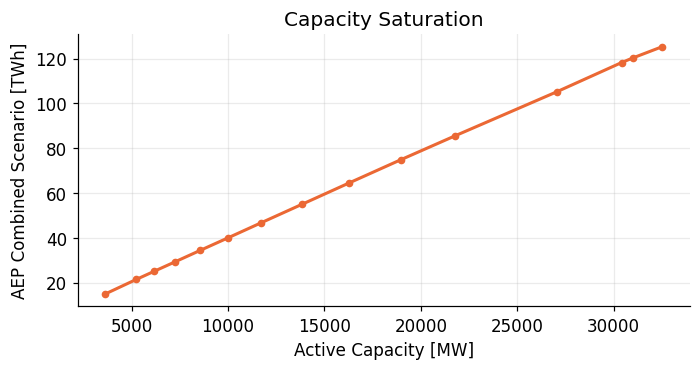

In [65]:
binned_line_plot(sat_table_s1_bk["active_mw"], sat_table_s1_bk["world_aep_twh"], COLOR_BK,
                  "Active Capacity [MW]", "AEP Combined Scenario [TWh]", "Capacity Saturation")

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Self Degradation'}, xlabel='Active Capacity [MW]', ylabel='AEP Self [GWh]'>)

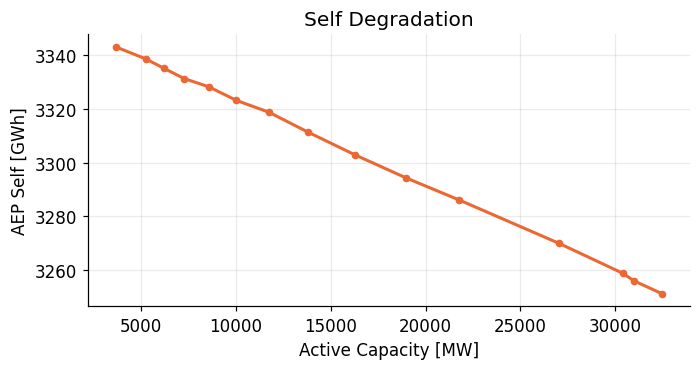

In [66]:
binned_line_plot(sat_table_s1_bk["active_mw"], sat_table_s1_bk["active_aep_gwh"], COLOR_BK,
                  "Active Capacity [MW]", "AEP Self [GWh]", "Self Degradation")

## Scenario 2, Super Gaussian model

In Scenario 2, the self already starts inside a more heavily loaded fixed cluster, and speculative expansion occurs as infill. So, unlike Scenario 1, wake loss is already at a high level from the first checkpoint. This section shows how the new combined-energy variable behaves in this scenario and how increasing capacity relates to an initial condition that is already more exposed.

## Scenario 2 -- Fixed cluster + speculative infill expansion -- Wake Model: SuperGaussian

### Phase 1 -- Ingestion, Audit & Correlation Screening

The audit again confirms 10,000 complete trials and, now, six segments per trial -- the original five checkpoints plus the backfilled 2050 full build-out snapshot. Climate inputs follow the same distribution used before, so the difference in Scenario 2 does not come from sampled climate. Mean density was 4.88 MW/km² and the mean number of speculative farms was 10.71, lower than in Scenario 1, which is consistent with infill expansion inside a region that already has more occupied areas.

In [67]:
trials_s2_sg.shape, arrivals_s2_sg.shape, segments_s2_sg.shape

((10000, 13), (237139, 9), (60000, 16))

In [68]:
trials_s2_sg.isna().sum().sum(), arrivals_s2_sg.isna().sum().sum(), segments_s2_sg.isna().sum().sum()

(np.int64(0), np.int64(140000), np.int64(0))

In [69]:
trials_s2_sg.trial_id.nunique(), segments_s2_sg.trial_id.nunique()  # integrity: every trial reached the final segment

(10000, 10000)

### Input Uncertainty

In [70]:
trials_s2_sg[['climate_rotation_deg', 'climate_speed_multiplier', 'climate_spread_multiplier']].describe()

,climate_rotation_deg,climate_speed_multiplier,climate_spread_multiplier
count,10000.000000,10000.000000,10000.000000
mean,-0.007173,0.999985,0.999829
std,1.458700,0.004755,0.025766
min,-3.935272,0.990664,0.941646
25%,-0.989038,0.996604,0.982145
50%,-0.020011,0.999940,0.999569
75%,0.990218,1.003288,1.017452
max,3.935272,1.010155,1.070733


In [71]:
final_s2_sg['mean_density_mw_km2'].describe()

count    10000.000000
mean         4.875858
std          0.241939
min          4.129346
25%          4.709026
50%          4.867692
75%          5.038731
max          5.794355
Name: mean_density_mw_km2, dtype: float64

In [72]:
final_s2_sg['n_speculative'].describe()

count    10000.000000
mean        10.713900
std          2.384788
min          3.000000
25%          9.000000
50%         11.000000
75%         12.000000
max         19.000000
Name: n_speculative, dtype: float64

### Correlation vs Outputs

In [73]:
predictors = ["climate_rotation_deg", "climate_speed_multiplier", "climate_spread_multiplier",
              "n_speculative", "mean_density_mw_km2", "active_mw", "n_active_turbines"]
targets = ["active_aep_gwh", "world_aep_gwh"]

pearson_s2_sg = final_s2_sg[predictors + targets].corr(method="pearson").loc[predictors, targets]
pearson_s2_sg

,active_aep_gwh,world_aep_gwh
climate_rotation_deg,0.039586,0.026677
climate_speed_multiplier,0.764860,0.209029
climate_spread_multiplier,0.131117,0.026770
n_speculative,-0.088369,0.243224
mean_density_mw_km2,0.019039,-0.171844
active_mw,-0.101095,0.860921
n_active_turbines,-0.077006,0.544073


In [74]:
spearman_s2_sg = final_s2_sg[predictors + targets].corr(method="spearman").loc[predictors, targets]
spearman_s2_sg

,active_aep_gwh,world_aep_gwh
climate_rotation_deg,0.042761,0.029975
climate_speed_multiplier,0.784336,0.235643
climate_spread_multiplier,0.122929,0.033143
n_speculative,-0.081822,0.272991
mean_density_mw_km2,0.026142,-0.196311
active_mw,-0.086222,0.795534
n_active_turbines,-0.063351,0.458086


In Scenario 2 with Super Gaussian, self AEP is most associated with the speed multiplier, with a correlation of 0.765. Combined AEP is most associated with active capacity, with 0.861, and turbine count, with 0.544 -- both weaker than a mid-horizon reading, for the same reason as Scenario 1: by 2050 capacity has converged close to the scenario's target across almost every trial, leaving relatively more of the remaining variance to turbine count, density, and climate. The main separation between the two metrics still holds: the energy of the whole world is mainly driven by scenario scale, while self production is more sensitive to climate and the wakes already around it.

In [75]:
pearson_s2_sg['active_aep_gwh'].sort_values(key=abs, ascending=False)  # ranked drivers of AEP Self

climate_speed_multiplier     0.764860
climate_spread_multiplier    0.131117
active_mw                   -0.101095
n_speculative               -0.088369
n_active_turbines           -0.077006
climate_rotation_deg         0.039586
mean_density_mw_km2          0.019039
Name: active_aep_gwh, dtype: float64

In [76]:
pearson_s2_sg['world_aep_gwh'].sort_values(key=abs, ascending=False)  # ranked drivers of AEP Combined Scenario

active_mw                    0.860921
n_active_turbines            0.544073
n_speculative                0.243224
climate_speed_multiplier     0.209029
mean_density_mw_km2         -0.171844
climate_spread_multiplier    0.026770
climate_rotation_deg         0.026677
Name: world_aep_gwh, dtype: float64

### Phase 2 -- Dual Energy & Risk Breakdown

The density and arrival distributions keep the same general rules used before, but they are now applied to the remaining space in Scenario 2. Even with fewer speculative farms on average, the final turbine count is still high because the scenario already starts with a fixed cluster and additional expansion is added on top of that base.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Turbine Density'}, xlabel='Turbine Density [MW/km²]', ylabel='Farms [count]'>)

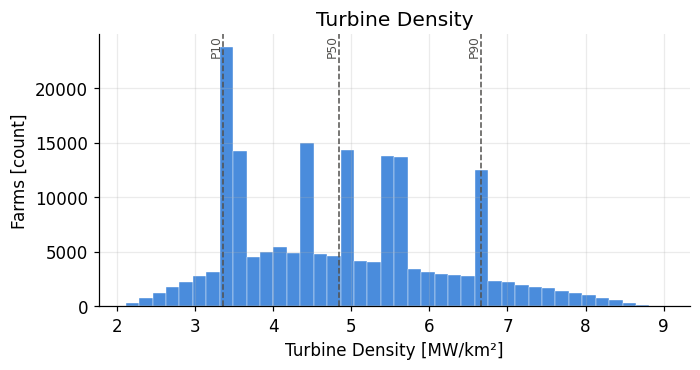

In [77]:
density = arrivals_s2_sg["rho_target_mw_km2"].dropna()
hist_with_percentiles(density, COLOR_SG, "Turbine Density [MW/km\u00b2]", "Farms [count]", "Turbine Density")

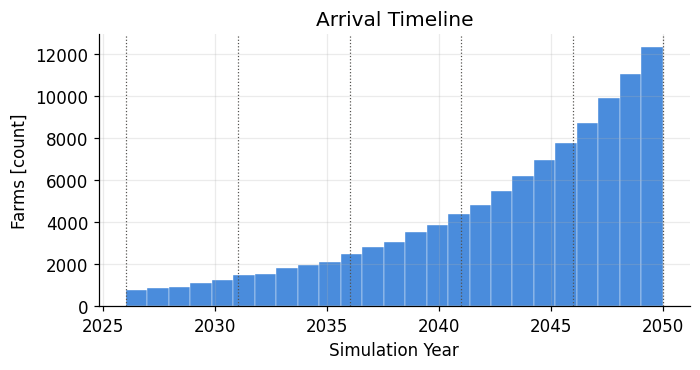

In [78]:
checkpoints = sorted(set(segments_s2_sg.start_year) | set(segments_s2_sg.end_year))
new_farm_years = arrivals_s2_sg.loc[arrivals_s2_sg.source == "speculative", "arrival_year"]
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.hist(new_farm_years, bins=25, color=COLOR_SG, alpha=0.85, edgecolor="white", linewidth=0.3)
for yr in checkpoints:
    ax.axvline(yr, color=COLOR_NEUTRAL, linestyle=":", linewidth=0.8)
ax.set_xlabel("Simulation Year"); ax.set_ylabel("Farms [count]"); ax.set_title("Arrival Timeline")
fig.tight_layout()

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Turbine Scale'}, xlabel='Active Turbines [count]', ylabel='Trials (Samples)'>)

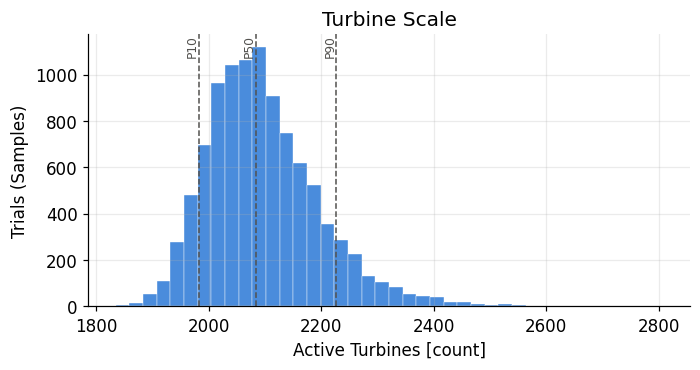

In [79]:
hist_with_percentiles(final_s2_sg["n_active_turbines"], COLOR_SG, "Active Turbines [count]", "Trials (Samples)", "Turbine Scale")

At the last checkpoint, self AEP has a P10 of approximately 2,838.2 GWh, a median of 2,874.6 GWh, and a P90 of 2,909.1 GWh -- lower across the board than a mid-horizon reading. The combined AEP of the scenario goes from 106.7 TWh at P10 to 115.9 TWh at P90, with a median of 110.3 TWh, much higher than a mid-horizon reading since the true endpoint captures the full regional build-out. At the same time, wake loss is at another level: P10 is 11.03%, the median is 11.58%, and P90 is 12.33% -- also higher than a mid-horizon reading. So Scenario 2 produces more total energy than Scenario 1 in most trials, but the self receives a much larger loss because it is already inside a more loaded region.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'AEP Distribution'}, xlabel='AEP Self [GWh]', ylabel='Trials (Samples)'>)

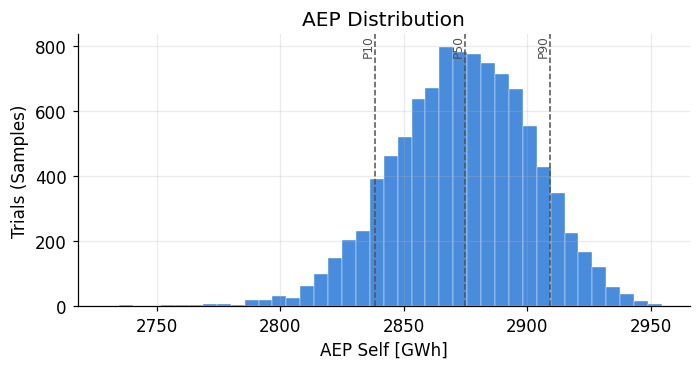

In [80]:
hist_with_percentiles(final_s2_sg["active_aep_gwh"], COLOR_SG, "AEP Self [GWh]", "Trials (Samples)", "AEP Distribution")

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'AEP Distribution'}, xlabel='AEP Combined Scenario [TWh]', ylabel='Trials (Samples)'>)

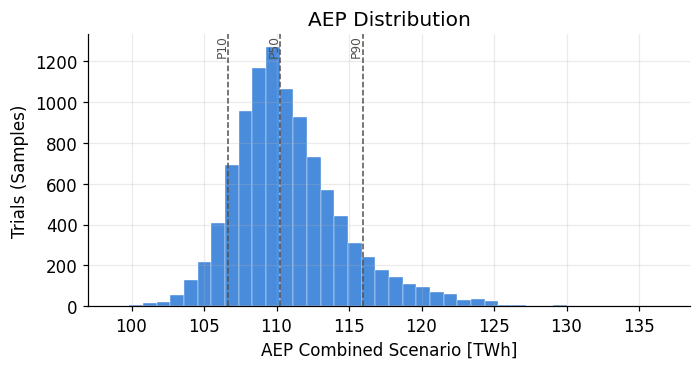

In [81]:
hist_with_percentiles(final_s2_sg["world_aep_gwh"] / 1000, COLOR_SG, "AEP Combined Scenario [TWh]", "Trials (Samples)", "AEP Distribution")

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Wake Loss'}, xlabel='Wake Loss Self [%]', ylabel='Trials (Samples)'>)

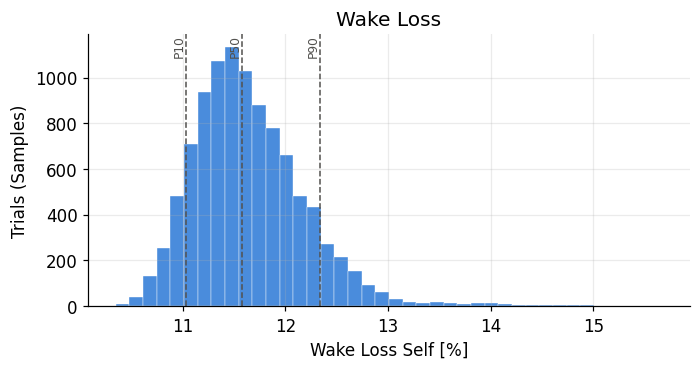

In [82]:
hist_with_percentiles(final_s2_sg["loss_pct"], COLOR_SG, "Wake Loss Self [%]", "Trials (Samples)", "Wake Loss")

The percentiles of self AEP, combined AEP, and wake loss are also tracked as the sample grows. The reading is the same as in the previous plots: checking whether the values used to compare scenarios have already stabilized near 10,000 trials without depending on a specific order of draws.

In [83]:
np.percentile(final_s2_sg['active_aep_gwh'], [10, 50, 90])  # converged P10/P50/P90, AEP Self

array([2838.17952172, 2874.6133584 , 2909.06174424])

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Risk Bands'}, xlabel='Trials (Samples)', ylabel='AEP Self [GWh]'>)

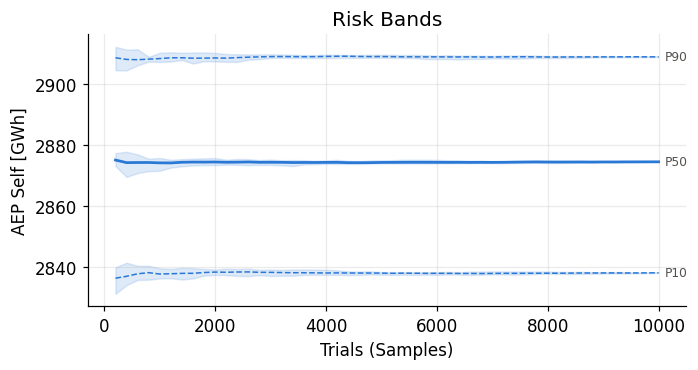

In [84]:
convergence_bands(final_s2_sg["active_aep_gwh"], COLOR_SG, "AEP Self [GWh]", "Risk Bands")

In [85]:
np.percentile(final_s2_sg['world_aep_gwh'] / 1000, [10, 50, 90])  # converged P10/P50/P90, AEP Combined

array([106.67586167, 110.27129561, 115.9435293 ])

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Risk Bands'}, xlabel='Trials (Samples)', ylabel='AEP Combined Scenario [TWh]'>)

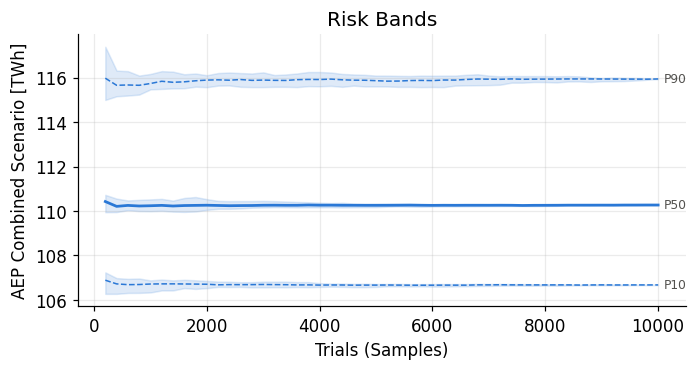

In [86]:
convergence_bands(final_s2_sg["world_aep_gwh"] / 1000, COLOR_SG, "AEP Combined Scenario [TWh]", "Risk Bands")

In [87]:
np.percentile(final_s2_sg['loss_pct'], [10, 50, 90])  # converged P10/P50/P90, Wake Loss Self

array([11.02993212, 11.57541651, 12.33325911])

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Risk Bands'}, xlabel='Trials (Samples)', ylabel='Wake Loss Self [%]'>)

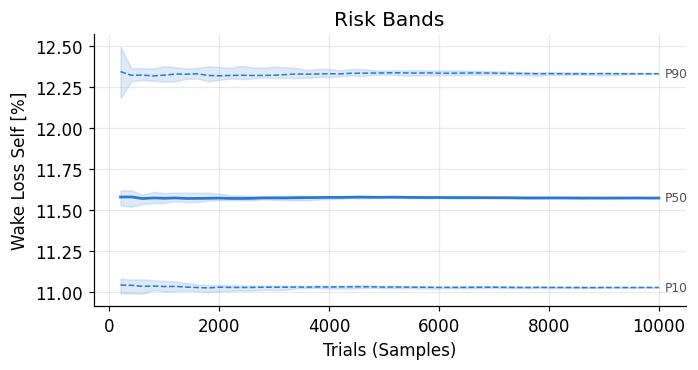

In [88]:
convergence_bands(final_s2_sg["loss_pct"], COLOR_SG, "Wake Loss Self [%]", "Risk Bands")

Wake loss starts near 10.2% at 2026 and now climbs all the way to approximately 11.6% at the true 2050 endpoint, while combined AEP grows as infill enters operation and now reaches its real full-build-out level too. Here it becomes clearer that expansion does not create risk from zero; it adds more uncertainty and more loss on top of an environment that already starts with relevant wakes.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Loss Trajectory'}, xlabel='Simulation Year', ylabel='Wake Loss Self [%]'>)

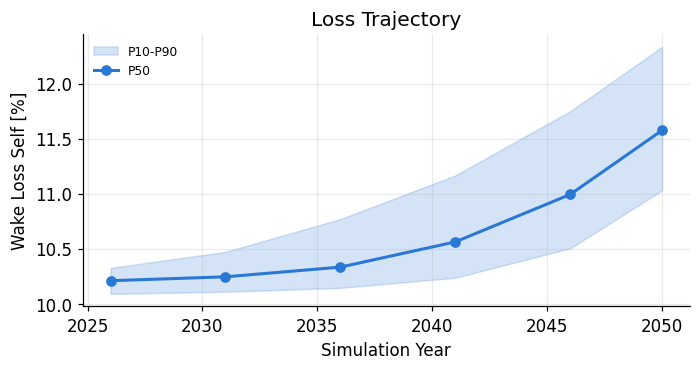

In [89]:
segment_trajectory(segments_s2_sg, COLOR_SG, "Wake Loss Self [%]", "Loss Trajectory", value_col="loss_pct")

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Combined Energy Growth'}, xlabel='Simulation Year', ylabel='AEP Combined Scenario [TWh]'>)

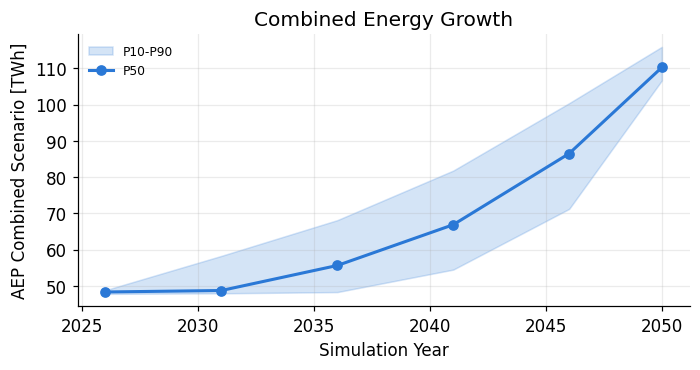

In [90]:
segments_s2_sg["world_aep_twh"] = segments_s2_sg["world_aep_gwh"] / 1000
segment_trajectory(segments_s2_sg, COLOR_SG, "AEP Combined Scenario [TWh]", "Combined Energy Growth", value_col="world_aep_twh")

### Phase 3 -- Regional Saturation & Cross-Variable Interaction

In [91]:
final_s2_sg[['world_aep_gwh', 'loss_pct']].corr().iloc[0, 1]  # Combined AEP growth vs Self wake loss, final segment

np.float64(0.10733482387815586)

The correlation between combined AEP and wake loss is 0.107 in Scenario 2, essentially the same near-zero reading as Scenario 1 (0.103) despite Scenario 2's much higher starting wake-loss level. So the effect is not scenario-specific: once nearly every trial has converged toward the same total build-out by 2050, combined AEP alone stops distinguishing which worlds hit the self harder -- geometry and the relative positions of farms remain what actually drives the spread.

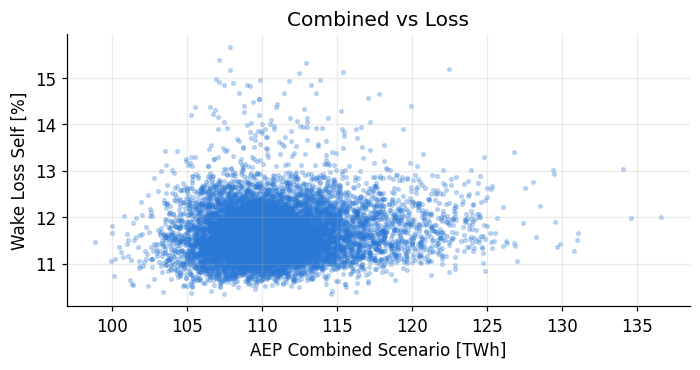

In [92]:
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.scatter(final_s2_sg["world_aep_gwh"] / 1000, final_s2_sg["loss_pct"], s=6, alpha=0.25, color=COLOR_SG)
ax.set_xlabel("AEP Combined Scenario [TWh]"); ax.set_ylabel("Wake Loss Self [%]"); ax.set_title("Combined vs Loss")
fig.tight_layout()

In [93]:
capacity_bins_s2_sg = segments_s2_sg.copy()
capacity_bins_s2_sg["capacity_bin"] = pd.qcut(capacity_bins_s2_sg["active_mw"], 20, duplicates="drop")
sat_table_s2_sg = capacity_bins_s2_sg.groupby("capacity_bin", observed=True).agg(
    active_mw=("active_mw", "mean"),
    world_aep_twh=("world_aep_gwh", lambda x: x.mean() / 1000),
    active_aep_gwh=("active_aep_gwh", "mean"),
).reset_index(drop=True)
sat_table_s2_sg

,active_mw,world_aep_twh,active_aep_gwh
0,13549.005497,48.688722,2920.309379
1,14907.168389,53.783366,2916.949418
2,15652.595987,56.460962,2913.848806
3,16530.239580,59.599499,2912.009116
4,17557.297667,63.233785,2909.636321
5,18752.546667,67.481047,2905.838896
6,20140.397901,72.378939,2902.733596
7,21734.087725,78.044827,2898.219370
8,23517.304667,84.310748,2894.096757
9,25630.146285,91.569732,2889.001793


In [94]:
np.diff(sat_table_s2_sg['world_aep_twh'])  # marginal TWh gained per capacity bin -- shrinking values = saturation

array([ 5.09464427,  2.67759582,  3.13853681,  3.63428596,  4.24726261,
        4.89789199,  5.66588758,  6.26592089,  7.258984  , 11.65839992,
        5.30975162,  1.94701862,  4.57429937])

Combined energy grows from approximately 48.7 TWh to 115.1 TWh between the extreme capacity bins, while mean self AEP decreases from approximately 2,920 GWh to 2,870 GWh. Both ends of this range are higher than a mid-horizon reading, since the top bin now reflects trials genuinely near the true full build-out; the decrease is still smaller in GWh than in Scenario 1, but it happens on top of an already high wake-loss level, so it does not mean that the scenario is less critical for the self.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Capacity Saturation'}, xlabel='Active Capacity [MW]', ylabel='AEP Combined Scenario [TWh]'>)

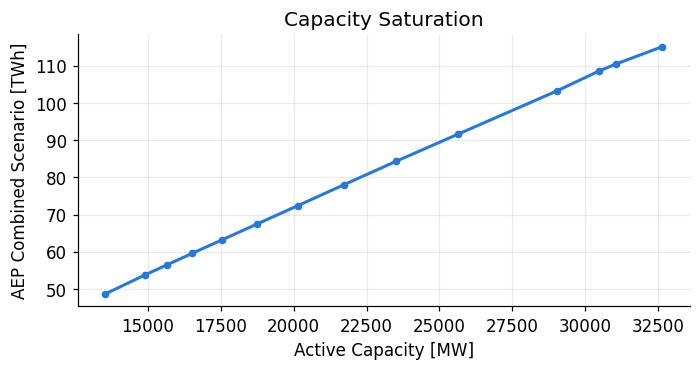

In [95]:
binned_line_plot(sat_table_s2_sg["active_mw"], sat_table_s2_sg["world_aep_twh"], COLOR_SG,
                  "Active Capacity [MW]", "AEP Combined Scenario [TWh]", "Capacity Saturation")

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Self Degradation'}, xlabel='Active Capacity [MW]', ylabel='AEP Self [GWh]'>)

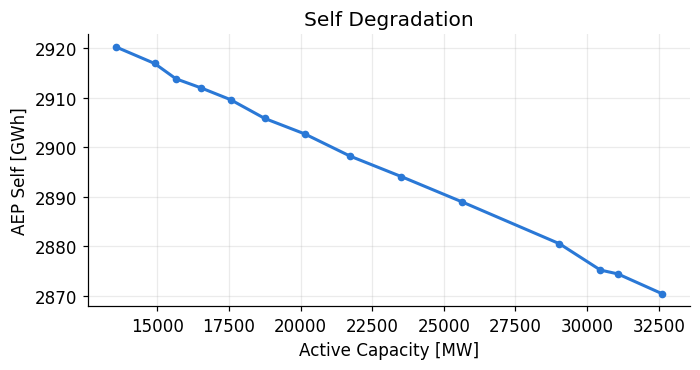

In [96]:
binned_line_plot(sat_table_s2_sg["active_mw"], sat_table_s2_sg["active_aep_gwh"], COLOR_SG,
                  "Active Capacity [MW]", "AEP Self [GWh]", "Self Degradation")

## Scenario 2, Bastankhah model

This section runs Bastankhah on the same Scenario 2 worlds that were just used with Super Gaussian. The equality check between `trials` and `arrivals` again confirms that the only change between the branches is the wake model.

## Scenario 2 -- Fixed cluster + speculative infill expansion -- Wake Model: Bastankhah

### Phase 1 -- Ingestion, Audit & Correlation Screening

In [97]:
trials_s2_bk.shape, arrivals_s2_bk.shape, segments_s2_bk.shape

((10000, 13), (237139, 9), (60000, 16))

In [98]:
trials_s2_bk.isna().sum().sum(), arrivals_s2_bk.isna().sum().sum(), segments_s2_bk.isna().sum().sum()

(np.int64(0), np.int64(140000), np.int64(0))

In [99]:
trials_s2_bk.trial_id.nunique(), segments_s2_bk.trial_id.nunique()  # integrity: every trial reached the final segment

(10000, 10000)

In [100]:
cols = ["seed", "n_speculative", "fixed_capacity_mw", "climate_rotation_deg", "climate_speed_multiplier", "climate_spread_multiplier"]
trials_s2_bk[cols].equals(trials_s2_sg[cols]), arrivals_s2_bk.equals(arrivals_s2_sg)

(True, True)

The input data again appear equal to those of Scenario 2 with Super Gaussian, including climate, mean density, and the number of speculative farms, and `segments` again has the same 60,000-row shape with the backfilled 2050 snapshot. Since this was already explained before, the focus here is on the new results that Bastankhah produces for the same set of scenarios.

### Input Uncertainty

In [101]:
trials_s2_bk[['climate_rotation_deg', 'climate_speed_multiplier', 'climate_spread_multiplier']].describe()

,climate_rotation_deg,climate_speed_multiplier,climate_spread_multiplier
count,10000.000000,10000.000000,10000.000000
mean,-0.007173,0.999985,0.999829
std,1.458700,0.004755,0.025766
min,-3.935272,0.990664,0.941646
25%,-0.989038,0.996604,0.982145
50%,-0.020011,0.999940,0.999569
75%,0.990218,1.003288,1.017452
max,3.935272,1.010155,1.070733


In [102]:
final_s2_bk['mean_density_mw_km2'].describe()

count    10000.000000
mean         4.875858
std          0.241939
min          4.129346
25%          4.709026
50%          4.867692
75%          5.038731
max          5.794355
Name: mean_density_mw_km2, dtype: float64

In [103]:
final_s2_bk['n_speculative'].describe()

count    10000.000000
mean        10.713900
std          2.384788
min          3.000000
25%          9.000000
50%         11.000000
75%         12.000000
max         19.000000
Name: n_speculative, dtype: float64

### Correlation vs Outputs

In [104]:
predictors = ["climate_rotation_deg", "climate_speed_multiplier", "climate_spread_multiplier",
              "n_speculative", "mean_density_mw_km2", "active_mw", "n_active_turbines"]
targets = ["active_aep_gwh", "world_aep_gwh"]

pearson_s2_bk = final_s2_bk[predictors + targets].corr(method="pearson").loc[predictors, targets]
pearson_s2_bk

,active_aep_gwh,world_aep_gwh
climate_rotation_deg,0.056807,0.021822
climate_speed_multiplier,0.887164,0.194053
climate_spread_multiplier,0.122945,0.021818
n_speculative,-0.051470,0.201821
mean_density_mw_km2,0.011850,-0.142072
active_mw,-0.078204,0.905627
n_active_turbines,-0.051555,0.594318


In [105]:
spearman_s2_bk = final_s2_bk[predictors + targets].corr(method="spearman").loc[predictors, targets]
spearman_s2_bk

,active_aep_gwh,world_aep_gwh
climate_rotation_deg,0.056690,0.025986
climate_speed_multiplier,0.894086,0.229824
climate_spread_multiplier,0.114934,0.029214
n_speculative,-0.048636,0.239386
mean_density_mw_km2,0.015885,-0.173629
active_mw,-0.063546,0.847131
n_active_turbines,-0.039953,0.505635


The general pattern remains: combined AEP is most associated with active capacity, with a correlation of 0.906, and turbine count, with 0.594. For self AEP, the speed multiplier is even more dominant, with a correlation of 0.887. Compared with Super Gaussian, Bastankhah keeps the same direction in the main relationships, and both models show the same weakening of the capacity correlations relative to a mid-horizon reading, for the same convergence-toward-target reason.

In [106]:
pearson_s2_bk['active_aep_gwh'].sort_values(key=abs, ascending=False)  # ranked drivers of AEP Self

climate_speed_multiplier     0.887164
climate_spread_multiplier    0.122945
active_mw                   -0.078204
climate_rotation_deg         0.056807
n_active_turbines           -0.051555
n_speculative               -0.051470
mean_density_mw_km2          0.011850
Name: active_aep_gwh, dtype: float64

In [107]:
pearson_s2_bk['world_aep_gwh'].sort_values(key=abs, ascending=False)  # ranked drivers of AEP Combined Scenario

active_mw                    0.905627
n_active_turbines            0.594318
n_speculative                0.201821
climate_speed_multiplier     0.194053
mean_density_mw_km2         -0.142072
climate_rotation_deg         0.021822
climate_spread_multiplier    0.021818
Name: world_aep_gwh, dtype: float64

### Phase 2 -- Dual Energy & Risk Breakdown

The density, arrival, and physical-scale distributions are the same as in the Super Gaussian block for Scenario 2, so these plots work here only as a visual confirmation that the same worlds were used in both models.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Turbine Density'}, xlabel='Turbine Density [MW/km²]', ylabel='Farms [count]'>)

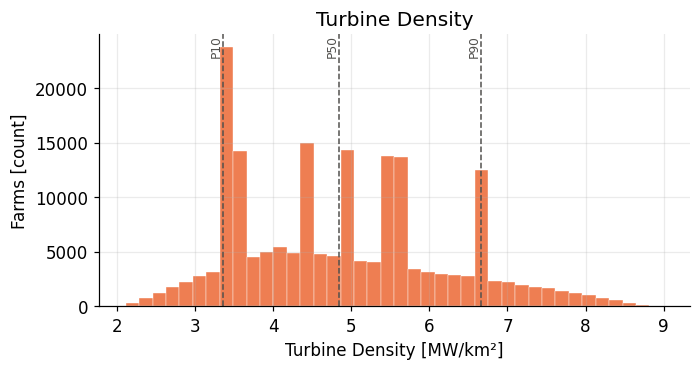

In [108]:
density = arrivals_s2_bk["rho_target_mw_km2"].dropna()
hist_with_percentiles(density, COLOR_BK, "Turbine Density [MW/km\u00b2]", "Farms [count]", "Turbine Density")

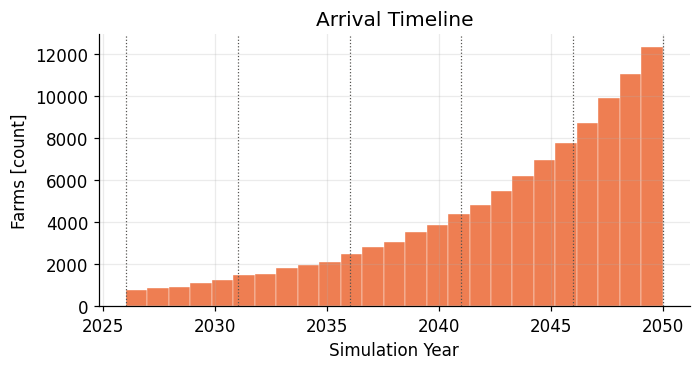

In [109]:
checkpoints = sorted(set(segments_s2_bk.start_year) | set(segments_s2_bk.end_year))
new_farm_years = arrivals_s2_bk.loc[arrivals_s2_bk.source == "speculative", "arrival_year"]
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.hist(new_farm_years, bins=25, color=COLOR_BK, alpha=0.85, edgecolor="white", linewidth=0.3)
for yr in checkpoints:
    ax.axvline(yr, color=COLOR_NEUTRAL, linestyle=":", linewidth=0.8)
ax.set_xlabel("Simulation Year"); ax.set_ylabel("Farms [count]"); ax.set_title("Arrival Timeline")
fig.tight_layout()

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Turbine Scale'}, xlabel='Active Turbines [count]', ylabel='Trials (Samples)'>)

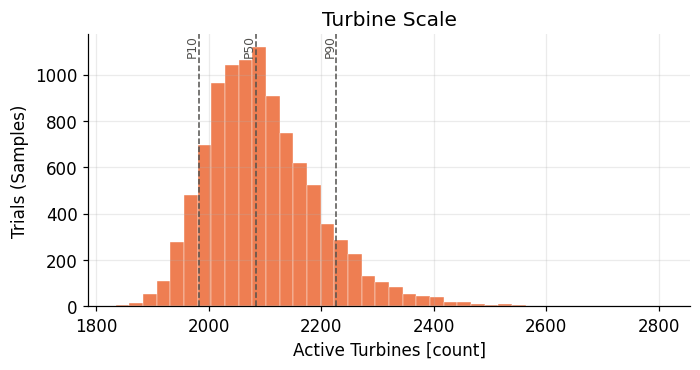

In [110]:
hist_with_percentiles(final_s2_bk["n_active_turbines"], COLOR_BK, "Active Turbines [count]", "Trials (Samples)", "Turbine Scale")

With Bastankhah, self AEP at the last checkpoint is a P10 of approximately 3,082.3 GWh, a median of 3,115.3 GWh, and a P90 of 3,147.4 GWh. Combined AEP has a median of 119.5 TWh, above the 110.3 TWh from Super Gaussian. Wake loss is a P10 of 7.07%, a median of 7.39%, and a P90 of 7.86%. As in Scenario 1, Bastankhah calculates lower loss for the self and more energy for the whole scenario while using exactly the same farm construction -- and, like every branch here, all of these numbers are higher than a mid-horizon reading now that the true 2050 build-out is being evaluated.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'AEP Distribution'}, xlabel='AEP Self [GWh]', ylabel='Trials (Samples)'>)

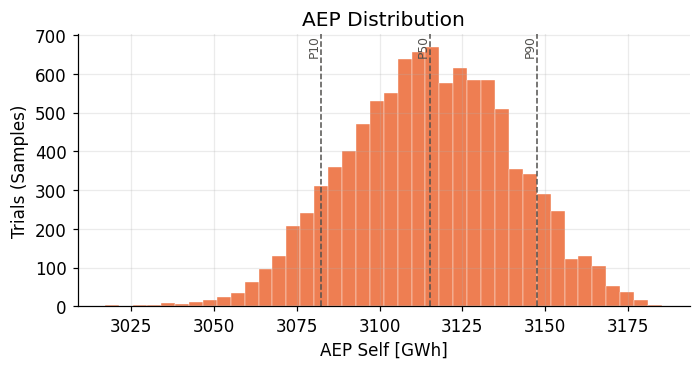

In [111]:
hist_with_percentiles(final_s2_bk["active_aep_gwh"], COLOR_BK, "AEP Self [GWh]", "Trials (Samples)", "AEP Distribution")

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'AEP Distribution'}, xlabel='AEP Combined Scenario [TWh]', ylabel='Trials (Samples)'>)

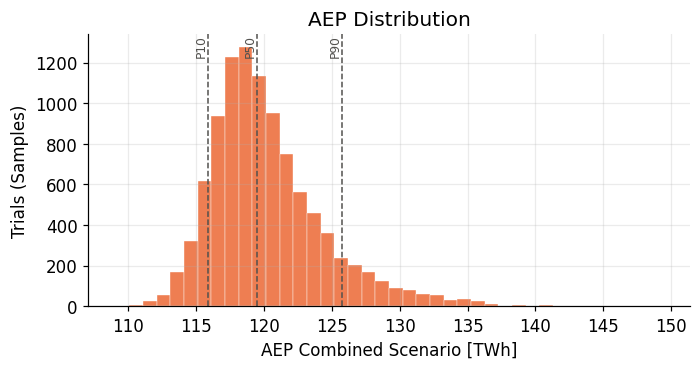

In [112]:
hist_with_percentiles(final_s2_bk["world_aep_gwh"] / 1000, COLOR_BK, "AEP Combined Scenario [TWh]", "Trials (Samples)", "AEP Distribution")

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Wake Loss'}, xlabel='Wake Loss Self [%]', ylabel='Trials (Samples)'>)

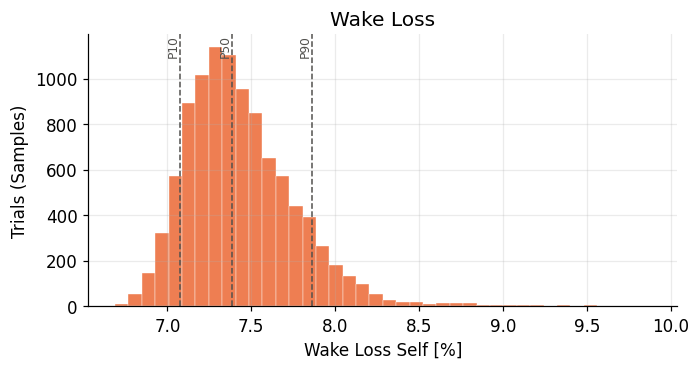

In [113]:
hist_with_percentiles(final_s2_bk["loss_pct"], COLOR_BK, "Wake Loss Self [%]", "Trials (Samples)", "Wake Loss")

Convergence and the trajectories confirm the same behavior seen before: the percentiles stabilize as the number of trials increases, combined energy grows over time all the way to its true 2050 level, and wake loss stays high while increasing through the horizon. The difference is that Bastankhah places this trajectory at a lower loss level than Super Gaussian.

In [114]:
np.percentile(final_s2_bk['active_aep_gwh'], [10, 50, 90])  # converged P10/P50/P90, AEP Self

array([3082.34270592, 3115.25211929, 3147.38334348])

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Risk Bands'}, xlabel='Trials (Samples)', ylabel='AEP Self [GWh]'>)

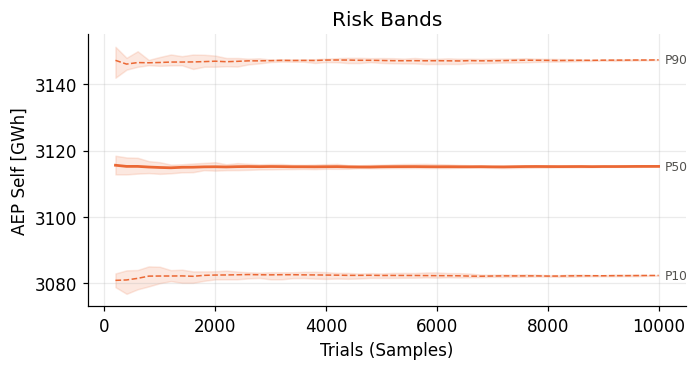

In [115]:
convergence_bands(final_s2_bk["active_aep_gwh"], COLOR_BK, "AEP Self [GWh]", "Risk Bands")

In [116]:
np.percentile(final_s2_bk['world_aep_gwh'] / 1000, [10, 50, 90])  # converged P10/P50/P90, AEP Combined

array([115.86380068, 119.46650186, 125.71858337])

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Risk Bands'}, xlabel='Trials (Samples)', ylabel='AEP Combined Scenario [TWh]'>)

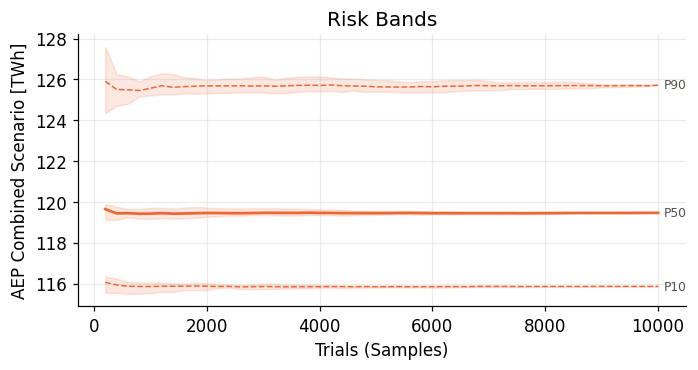

In [117]:
convergence_bands(final_s2_bk["world_aep_gwh"] / 1000, COLOR_BK, "AEP Combined Scenario [TWh]", "Risk Bands")

In [118]:
np.percentile(final_s2_bk['loss_pct'], [10, 50, 90])  # converged P10/P50/P90, Wake Loss Self

array([7.07393513, 7.38646623, 7.86029814])

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Risk Bands'}, xlabel='Trials (Samples)', ylabel='Wake Loss Self [%]'>)

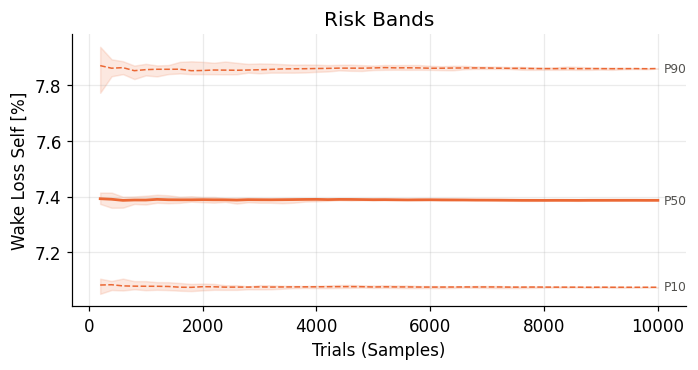

In [119]:
convergence_bands(final_s2_bk["loss_pct"], COLOR_BK, "Wake Loss Self [%]", "Risk Bands")

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Loss Trajectory'}, xlabel='Simulation Year', ylabel='Wake Loss Self [%]'>)

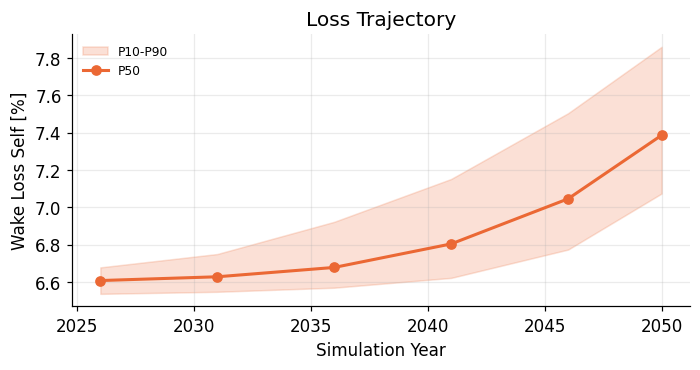

In [120]:
segment_trajectory(segments_s2_bk, COLOR_BK, "Wake Loss Self [%]", "Loss Trajectory", value_col="loss_pct")

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Combined Energy Growth'}, xlabel='Simulation Year', ylabel='AEP Combined Scenario [TWh]'>)

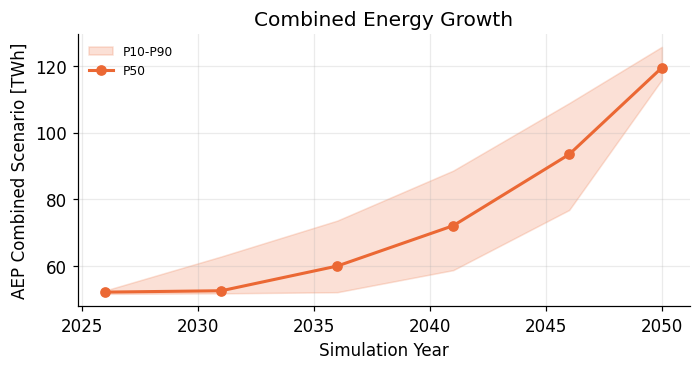

In [121]:
segments_s2_bk["world_aep_twh"] = segments_s2_bk["world_aep_gwh"] / 1000
segment_trajectory(segments_s2_bk, COLOR_BK, "AEP Combined Scenario [TWh]", "Combined Energy Growth", value_col="world_aep_twh")

### Phase 3 -- Regional Saturation & Cross-Variable Interaction

In [122]:
final_s2_bk[['world_aep_gwh', 'loss_pct']].corr().iloc[0, 1]  # Combined AEP growth vs Self wake loss, final segment

np.float64(0.10912463483177595)

The correlation between combined energy and wake loss is 0.109, essentially the same near-zero reading found with Super Gaussian (0.107) in this scenario. So the two models agree again: once total build-out converges toward the same target by 2050, combined AEP stops being a useful predictor of the self's loss, even in Scenario 2's already-loaded starting condition.

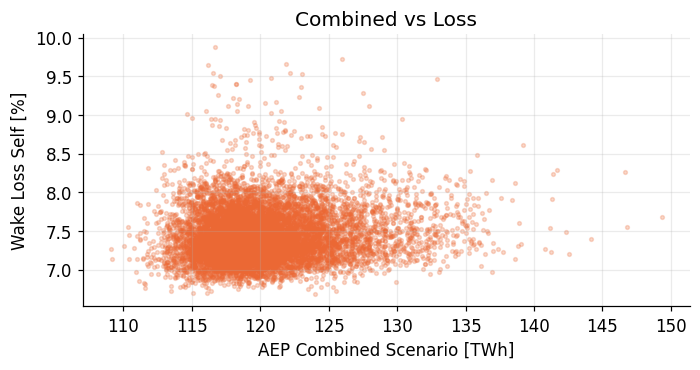

In [123]:
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.scatter(final_s2_bk["world_aep_gwh"] / 1000, final_s2_bk["loss_pct"], s=6, alpha=0.25, color=COLOR_BK)
ax.set_xlabel("AEP Combined Scenario [TWh]"); ax.set_ylabel("Wake Loss Self [%]"); ax.set_title("Combined vs Loss")
fig.tight_layout()

In [124]:
capacity_bins_s2_bk = segments_s2_bk.copy()
capacity_bins_s2_bk["capacity_bin"] = pd.qcut(capacity_bins_s2_bk["active_mw"], 20, duplicates="drop")
sat_table_s2_bk = capacity_bins_s2_bk.groupby("capacity_bin", observed=True).agg(
    active_mw=("active_mw", "mean"),
    world_aep_twh=("world_aep_gwh", lambda x: x.mean() / 1000),
    active_aep_gwh=("active_aep_gwh", "mean"),
).reset_index(drop=True)
sat_table_s2_bk

,active_mw,world_aep_twh,active_aep_gwh
0,13549.005497,52.586485,3142.926382
1,14907.168389,58.017646,3141.241897
2,15652.595987,60.902563,3139.034581
3,16530.239580,64.287578,3138.035869
4,17557.297667,68.228089,3136.768752
5,18752.546667,72.825708,3134.297325
6,20140.397901,78.146103,3132.586125
7,21734.087725,84.288940,3129.676448
8,23517.304667,91.119780,3127.413092
9,25630.146285,99.087897,3124.552593


In [125]:
np.diff(sat_table_s2_bk['world_aep_twh'])  # marginal TWh gained per capacity bin -- shrinking values = saturation

array([ 5.43116086,  2.88491789,  3.38501483,  3.9405112 ,  4.59761851,
        5.32039496,  6.14283744,  6.83083985,  7.96811686, 12.79464453,
        5.73330953,  2.1631488 ,  5.21139265])

The capacity-bin reading repeats the trade-off seen in the other blocks. Combined energy increases from approximately 52.6 TWh to 125.0 TWh, while self AEP decreases from approximately 3,143 GWh to 3,113 GWh. The decrease is still smaller than with Super Gaussian, but it follows the same direction, and both ends of the range are higher than a mid-horizon reading now that the top bin reflects trials genuinely near the true full build-out.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Capacity Saturation'}, xlabel='Active Capacity [MW]', ylabel='AEP Combined Scenario [TWh]'>)

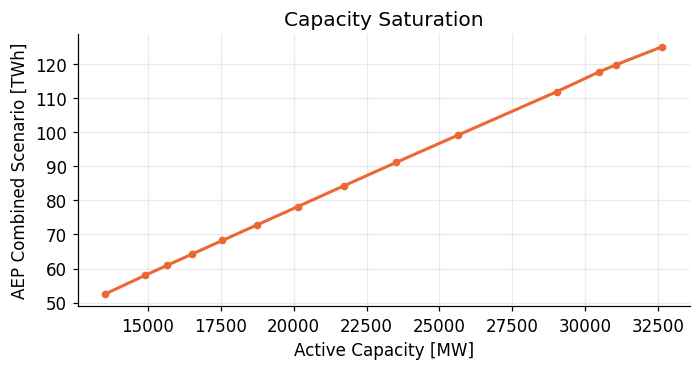

In [126]:
binned_line_plot(sat_table_s2_bk["active_mw"], sat_table_s2_bk["world_aep_twh"], COLOR_BK,
                  "Active Capacity [MW]", "AEP Combined Scenario [TWh]", "Capacity Saturation")

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Self Degradation'}, xlabel='Active Capacity [MW]', ylabel='AEP Self [GWh]'>)

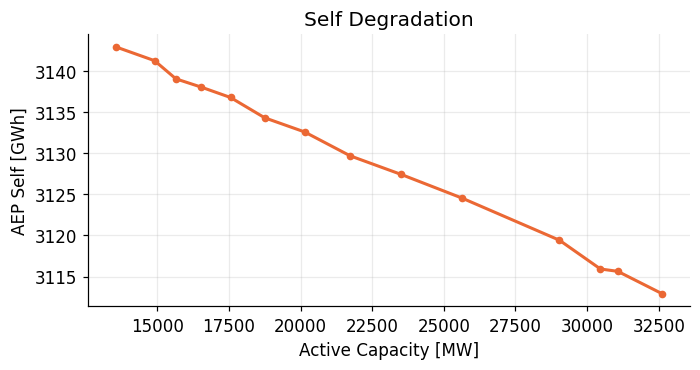

In [127]:
binned_line_plot(sat_table_s2_bk["active_mw"], sat_table_s2_bk["active_aep_gwh"], COLOR_BK,
                  "Active Capacity [MW]", "AEP Self [GWh]", "Self Degradation")

# Comparison between the wake models

After analyzing each branch separately, this section compares Super Gaussian and Bastankhah directly. Since the same scenarios were used in both models, the differences observed here are not caused by different density, arrival, capacity, or climate. They show model uncertainty, meaning how much the wake-loss and AEP response changes when the same physical situation is calculated with two wake formulations.

## Scenario 1, difference between models

## Scenario 1 -- Inter-Model Synthesis (Phase 4)

### Direct Wake Model Comparison

In Scenario 1, the two wake-loss distributions are clearly separated. Super Gaussian has a median of 5.34%, while Bastankhah has 3.07%, a difference of approximately 2.27 percentage points. At P90, Super Gaussian reaches 8.11% and Bastankhah 4.82%, a difference of approximately 3.29 percentage points -- both gaps wider than at a mid-horizon reading, since the true 2050 build-out gives the two models more total wake interaction to disagree about. So the divergence does not appear only in the central result; it also increases in the worlds with higher loss.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Wake Loss Comparison'}, xlabel='Wake Loss Self [%]', ylabel='Trials (Samples)'>)

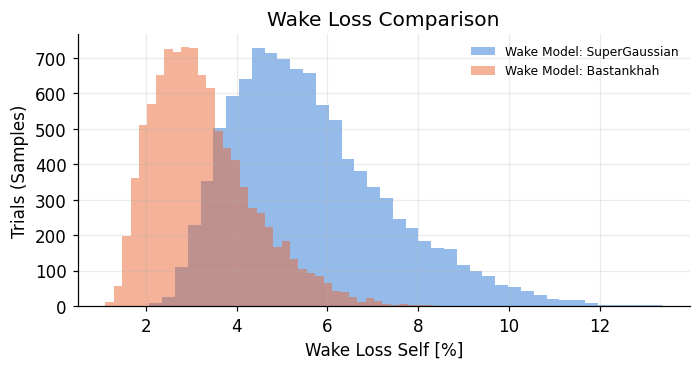

In [128]:
overlay_hist(final_s1_sg["loss_pct"], "Wake Model: SuperGaussian", COLOR_SG,
             final_s1_bk["loss_pct"], "Wake Model: Bastankhah", COLOR_BK,
             "Wake Loss Self [%]", "Trials (Samples)", "Wake Loss Comparison")

The trajectories show that both models agree that wake loss grows with scenario development, but Bastankhah keeps lower losses throughout the whole horizon, now visibly out to the true 2050 endpoint. The distance between the curves increases toward the end, when more capacity has already been built, so model choice becomes more important precisely in the worlds with greater regional development.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Model Divergence'}, xlabel='Simulation Year', ylabel='Wake Loss Self [%]'>)

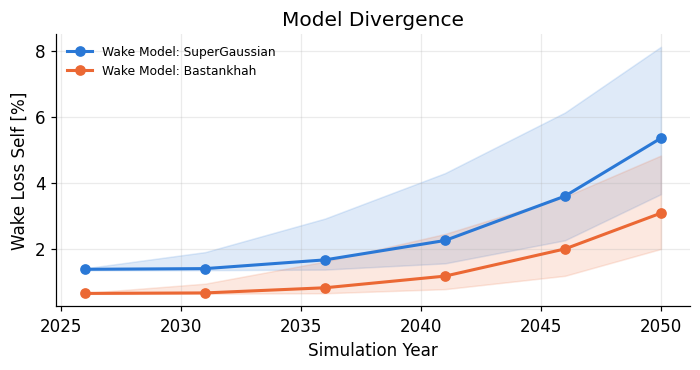

In [129]:
overlay_trajectory(segments_s1_sg, "Wake Model: SuperGaussian", COLOR_SG,
                    segments_s1_bk, "Wake Model: Bastankhah", COLOR_BK,
                    "Wake Loss Self [%]", "Model Divergence", value_col="loss_pct")

### Far-Wake Divergence Analysis

The difference between the models also appears when wake loss is related to active capacity. The estimated slope is approximately 0.000142 percentage points per MW for Super Gaussian and 0.000092 for Bastankhah -- close to a mid-horizon estimate, since this is a rate rather than an absolute level. These values should not be read as a simple causal relationship per MW, but they help summarize that, within this set of trials, Super Gaussian responds more strongly to increasing regional capacity.

In [130]:
p50_sg, p90_sg = np.percentile(final_s1_sg["loss_pct"], [50, 90])
p50_bk, p90_bk = np.percentile(final_s1_bk["loss_pct"], [50, 90])
{"P50_SuperGaussian": p50_sg, "P50_Bastankhah": p50_bk, "P50_delta": p50_sg - p50_bk,
  "P90_SuperGaussian": p90_sg, "P90_Bastankhah": p90_bk, "P90_delta": p90_sg - p90_bk}

{'P50_SuperGaussian': np.float64(5.344596809398341),
 'P50_Bastankhah': np.float64(3.0748193148978222),
 'P50_delta': np.float64(2.269777494500519),
 'P90_SuperGaussian': np.float64(8.112128149232205),
 'P90_Bastankhah': np.float64(4.81855482373379),
 'P90_delta': np.float64(3.293573325498415)}

In [131]:
slope_sg = np.polyfit(final_s1_sg["active_mw"], final_s1_sg["loss_pct"], 1)[0]
slope_bk = np.polyfit(final_s1_bk["active_mw"], final_s1_bk["loss_pct"], 1)[0]
{"slope_pct_per_MW_SuperGaussian": slope_sg, "slope_pct_per_MW_Bastankhah": slope_bk}

{'slope_pct_per_MW_SuperGaussian': np.float64(0.0001417204326119188),
 'slope_pct_per_MW_Bastankhah': np.float64(9.203454468721763e-05)}

The scatter plot shows the same idea visually. For the same active-capacity range, the Super Gaussian cloud sits above the Bastankhah cloud in most cases. There is still spread within each model because farm locations and climate change across trials, but the separation between the clouds shows that model difference is relevant for risk estimation.

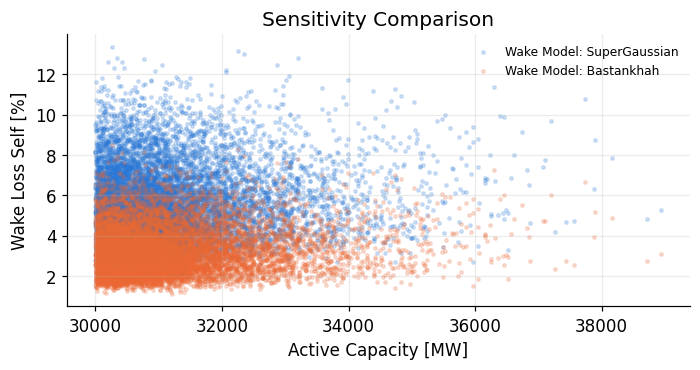

In [132]:
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.scatter(final_s1_sg["active_mw"], final_s1_sg["loss_pct"], s=5, alpha=0.2, color=COLOR_SG, label="Wake Model: SuperGaussian")
ax.scatter(final_s1_bk["active_mw"], final_s1_bk["loss_pct"], s=5, alpha=0.2, color=COLOR_BK, label="Wake Model: Bastankhah")
ax.set_xlabel("Active Capacity [MW]"); ax.set_ylabel("Wake Loss Self [%]"); ax.set_title("Sensitivity Comparison")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()

## Scenario 2, difference between models

In Scenario 2, both models continue to show a more heavily loaded region than in Scenario 1, but the difference between them becomes even larger in absolute terms. This matters because the scenario already starts with high wake loss, so model uncertainty is added to a regional condition that is already more critical for the self.

## Scenario 2 -- Inter-Model Synthesis (Phase 4)

### Direct Wake Model Comparison

In Scenario 2, Super Gaussian has a median wake loss of 11.58%, while Bastankhah has 7.39%, a difference of approximately 4.19 percentage points. At P90, the difference is approximately 4.47 percentage points, with 12.33% for Super Gaussian and 7.86% for Bastankhah -- both gaps a little wider than at a mid-horizon reading. Both models still agree that Scenario 2 has higher losses than Scenario 1, but they disagree in an important way on the level of that loss.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Wake Loss Comparison'}, xlabel='Wake Loss Self [%]', ylabel='Trials (Samples)'>)

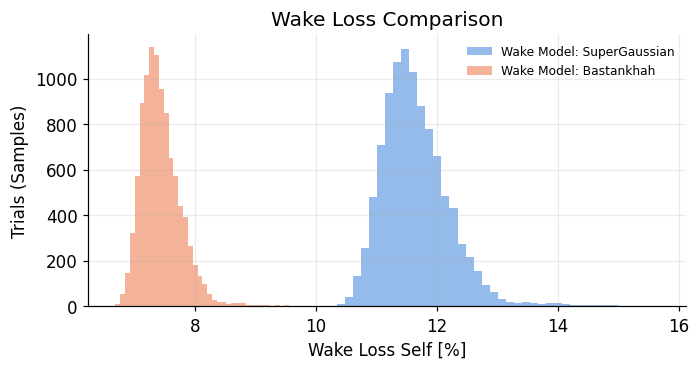

In [133]:
overlay_hist(final_s2_sg["loss_pct"], "Wake Model: SuperGaussian", COLOR_SG,
             final_s2_bk["loss_pct"], "Wake Model: Bastankhah", COLOR_BK,
             "Wake Loss Self [%]", "Trials (Samples)", "Wake Loss Comparison")

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Model Divergence'}, xlabel='Simulation Year', ylabel='Wake Loss Self [%]'>)

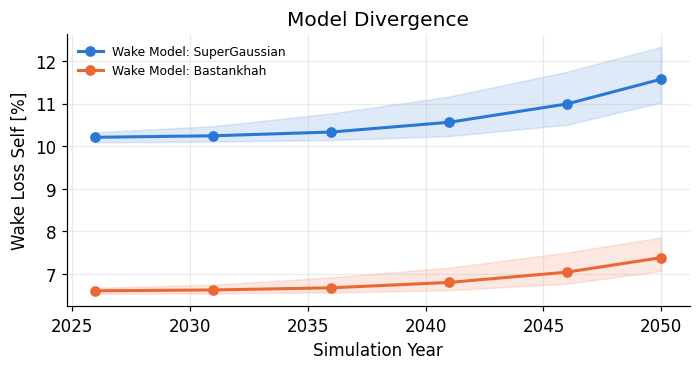

In [134]:
overlay_trajectory(segments_s2_sg, "Wake Model: SuperGaussian", COLOR_SG,
                    segments_s2_bk, "Wake Model: Bastankhah", COLOR_BK,
                    "Wake Loss Self [%]", "Model Divergence", value_col="loss_pct")

### Far-Wake Divergence Analysis

The relationship with capacity also remains positive in both models, but Super Gaussian continues to have a larger slope, approximately 0.000070 percentage points per MW compared with 0.000043 for Bastankhah -- close to a mid-horizon estimate, since slope is a rate, not an absolute level. The difference is smaller than in Scenario 1 because Scenario 2 already starts under a high-loss condition, but the plots show that increasing capacity still comes with increasing wake loss and that Super Gaussian remains more sensitive to this growth.

In [135]:
p50_sg, p90_sg = np.percentile(final_s2_sg["loss_pct"], [50, 90])
p50_bk, p90_bk = np.percentile(final_s2_bk["loss_pct"], [50, 90])
{"P50_SuperGaussian": p50_sg, "P50_Bastankhah": p50_bk, "P50_delta": p50_sg - p50_bk,
  "P90_SuperGaussian": p90_sg, "P90_Bastankhah": p90_bk, "P90_delta": p90_sg - p90_bk}

{'P50_SuperGaussian': np.float64(11.575416509555904),
 'P50_Bastankhah': np.float64(7.386466230398203),
 'P50_delta': np.float64(4.188950279157701),
 'P90_SuperGaussian': np.float64(12.333259105260035),
 'P90_Bastankhah': np.float64(7.860298135877076),
 'P90_delta': np.float64(4.472960969382959)}

In [136]:
slope_sg = np.polyfit(final_s2_sg["active_mw"], final_s2_sg["loss_pct"], 1)[0]
slope_bk = np.polyfit(final_s2_bk["active_mw"], final_s2_bk["loss_pct"], 1)[0]
{"slope_pct_per_MW_SuperGaussian": slope_sg, "slope_pct_per_MW_Bastankhah": slope_bk}

{'slope_pct_per_MW_SuperGaussian': np.float64(7.00305273805238e-05),
 'slope_pct_per_MW_Bastankhah': np.float64(4.342792728152918e-05)}

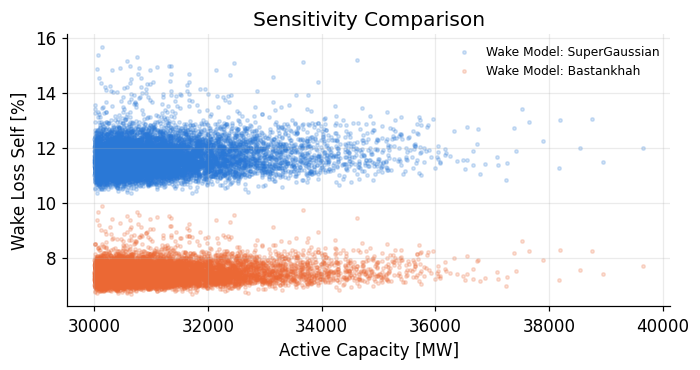

In [137]:
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.scatter(final_s2_sg["active_mw"], final_s2_sg["loss_pct"], s=5, alpha=0.2, color=COLOR_SG, label="Wake Model: SuperGaussian")
ax.scatter(final_s2_bk["active_mw"], final_s2_bk["loss_pct"], s=5, alpha=0.2, color=COLOR_BK, label="Wake Model: Bastankhah")
ax.set_xlabel("Active Capacity [MW]"); ax.set_ylabel("Wake Loss Self [%]"); ax.set_title("Sensitivity Comparison")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()

## Final synthesis

The ensemble analysis shows two different sources of variation. The first comes from the scenarios themselves, which change the number of farms, total capacity, density, arrival, and geometry of offshore development. The second comes from the wake model used to evaluate these same worlds. Both models agree on the general reading: greater active capacity increases the combined AEP of the scenario and tends to increase wake loss at the self, especially in Scenario 2, which already starts in a more heavily loaded environment. But they disagree on the magnitude of the losses, with Super Gaussian calculating higher wake loss and lower AEP for the self and for the whole scenario -- and that gap between models widens, not narrows, once the true 2050 full build-out is used instead of a mid-horizon proxy. For this reason, combined AEP helps show the regional benefit of expansion, while self wake loss shows the local cost of that same expansion -- though at the true endpoint, combined AEP on its own stops predicting that local cost well, since nearly every trial converges toward the same ~30 GW regional target; what still drives the spread in self's loss is where capacity landed, not just how much of it there was. Using both models makes it clear that risk analysis does not depend only on which farms will be built, but also on how wake interactions are represented.